# 07. Nonlinear functional robustness

## Objective

This controlled single-seed experiment asks whether the frozen Simple Event Volatility Model workflow remains informative when the data-generating functions for $\alpha_i$, $\nu_i$, and $\rho_i$ depart from their benchmark forms. It distinguishes a **functional-form change** from a scalar parameter change: the benchmark scalar configuration, event calendar, response horizon, estimator, and forecasting workflow remain fixed.

The powered volatility state is

$$
X_i = \sigma_i^n.
$$

This notebook is restricted to $n=1$, so $X_i=\sigma_i$. The inherited timing is

$$
E_i \longrightarrow \omega_{i+1} \longrightarrow X_{i+1}.
$$

An event at transition $i$ affects $X_{i+1}$; event ages $0,\ldots,h$ therefore map to TDMI state lags $+1,\ldots,h+1$.

Notebook 06 supplies the frozen methodology. No estimator is redesigned here, no hidden DGP quantity enters fitting, and no Monte Carlo replication is performed.

## 1. Load the frozen workflow

Notebook 07 directly loads Notebook 06 with its self-tests disabled. The available interfaces are inspected before use; workflow helpers are not redefined here.

In [1]:
RUN_HELPER_SELF_TESTS = False
%run "./06_experiment_workflow_helpers.ipynb"

import inspect
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

required_workflow_functions = {
    'run_full_pipeline': run_full_pipeline,
    'summarise_case': summarise_case,
    'make_case_config': make_case_config,
    'make_shock_bank': make_shock_bank,
    'derive_timing': derive_timing,
}
assert all(callable(function) for function in required_workflow_functions.values())
workflow_interface = inspect.signature(run_full_pipeline)
print('run_full_pipeline interface:', workflow_interface)
print('Notebook 06 helpers loaded; helper self-tests were intentionally skipped.')

Helper self-tests skipped for downstream use.
run_full_pipeline interface: (case_config, shock_bank=None, seed=None, baseline_feature_builder=None, include_causality=True, include_intervals=True, include_truth=False, functions=None)
Notebook 06 helpers loaded; helper self-tests were intentionally skipped.


## 2. Benchmark configuration and common shocks

The benchmark configuration and its validated shock generator are inherited from Notebook 06. Notebook 00 supplies time in **years** (the grid is transition index divided by trading steps per year), so $\sin(2\pi t)$ is one full cycle per model year. The same standard-normal epsilon and eta arrays are supplied to every case.

In [2]:
benchmark_case = make_case_config(reference_config, label='benchmark')
benchmark_timing = derive_timing(benchmark_case)
common_shock_bank = make_shock_bank(benchmark_case)
common_seed = benchmark_case['simulation']['seed']

assert benchmark_case['model']['n'] == 1
assert set(common_shock_bank) == {'z_epsilon', 'z_eta'}
assert len(common_shock_bank['z_epsilon']) == len(common_shock_bank['z_eta'])
print(f'Common shock seed: {common_seed}; transitions: {len(common_shock_bank["z_epsilon"])}.')
print('Time argument is annual model time; time-varying functions use sin(2*pi*t).')

Common shock seed: 20260721; transitions: 504.
Time argument is annual model time; time-varying functions use sin(2*pi*t).


## 3. Alternative data-generating functionals

Every function uses Notebook 06's native positional interface `function(t, S, sigma, returns, params)` and reads constants from `params`. Define the normalised volatility-state deviation as

$$
z_i = \frac{\sigma_i-\theta}{\theta}.
$$

### Bounded nonlinear alpha

$$
\alpha_i^{(\mathrm{bounded})} = -\frac{\kappa\theta}{3}\tanh(3z_i).
$$

Near equilibrium this agrees locally with linear mean reversion. Far from equilibrium its restoring force saturates, so extreme states receive weaker correction.

### Superlinear alpha

$$
\alpha_i^{(\mathrm{superlinear})} = \kappa(\theta-\sigma_i)(1+4z_i^2).
$$

This remains close to the benchmark near $\theta$, but strengthens mean reversion as the volatility state moves farther away.

### State-dependent nu

$$
\nu_i^{(\mathrm{state})} = \nu_0[1+0.5\tanh(3z_i)].
$$

It remains strictly positive and varies smoothly between one half and one and a half times $\nu_0$. It makes transition uncertainty depend on the current volatility state.

### Time-varying nu

$$
\nu_i^{(\mathrm{time})} = \nu_0[1+0.4\sin(2\pi t_i)].
$$

Notebook 00 passes $t_i$ in years, so this produces one complete cycle per model year. It changes background innovation scale without using the current state.

### State-dependent rho

$$
\rho_i^{(\mathrm{state})} = \tanh\!\left[\operatorname{arctanh}(\rho_0)-1.5z_i\right].
$$

The $\tanh$ map keeps correlation strictly inside $(-1,1)$. Above $\theta$, correlation becomes more negative, changing how much of the volatility shock is revealed by the observed price shock.

### Time-varying rho

$$
\rho_i^{(\mathrm{time})} = \tanh\!\left[\operatorname{arctanh}(\rho_0)+0.6\sin(2\pi t_i)\right].
$$

This also completes one cycle per model year while preserving valid correlation bounds. The event-weight function and all scalar benchmark parameters remain unchanged.

In [3]:
def _normalised_state_deviation(sigma, params):
    theta = float(params['theta'])
    return (float(sigma) - theta) / max(theta, 1e-12)


def alpha_bounded_nonlinear(t, S, sigma, returns, params):
    z = _normalised_state_deviation(sigma, params)
    return float(-(params['kappa'] * params['theta'] / 3.0) * np.tanh(3.0 * z))


def alpha_superlinear(t, S, sigma, returns, params):
    z = _normalised_state_deviation(sigma, params)
    return float(params['kappa'] * (params['theta'] - sigma) * (1.0 + 4.0 * z ** 2))


def nu_state_dependent(t, S, sigma, returns, params):
    z = _normalised_state_deviation(sigma, params)
    return float(params['nu_0'] * (1.0 + 0.5 * np.tanh(3.0 * z)))


def nu_time_varying(t, S, sigma, returns, params):
    return float(params['nu_0'] * (1.0 + 0.4 * np.sin(2.0 * np.pi * t)))


def _safe_atanh_rho(params):
    rho_0 = float(params['rho_0'])
    return np.arctanh(np.clip(rho_0, -1.0 + 1e-12, 1.0 - 1e-12))


def rho_state_dependent(t, S, sigma, returns, params):
    z = _normalised_state_deviation(sigma, params)
    return float(np.tanh(_safe_atanh_rho(params) - 1.5 * z))


def rho_time_varying(t, S, sigma, returns, params):
    return float(np.tanh(_safe_atanh_rho(params) + 0.6 * np.sin(2.0 * np.pi * t)))

alternative_functions = {
    'alpha_bounded_nonlinear': alpha_bounded_nonlinear,
    'alpha_superlinear': alpha_superlinear,
    'nu_state_dependent': nu_state_dependent,
    'nu_time_varying': nu_time_varying,
    'rho_state_dependent': rho_state_dependent,
    'rho_time_varying': rho_time_varying,
}
assert all(callable(function) for function in alternative_functions.values())

## 4. Functional diagnostics before simulation

The following diagnostic plots evaluate the functions directly. They verify finite outputs, positive nu, valid rho, local benchmark agreement at equilibrium, and meaningful departures away from equilibrium or across time.

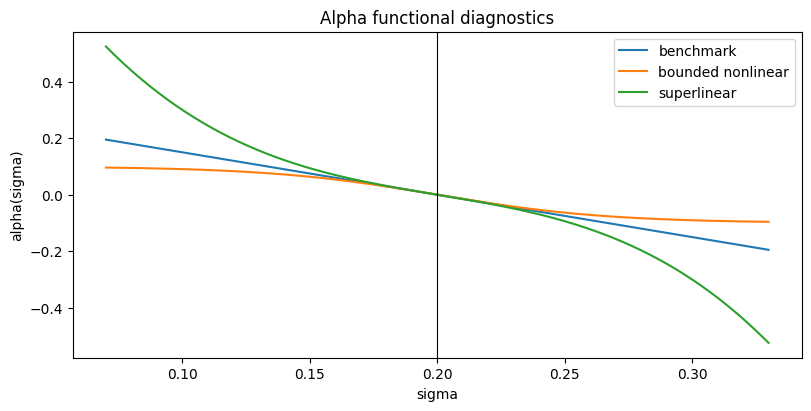

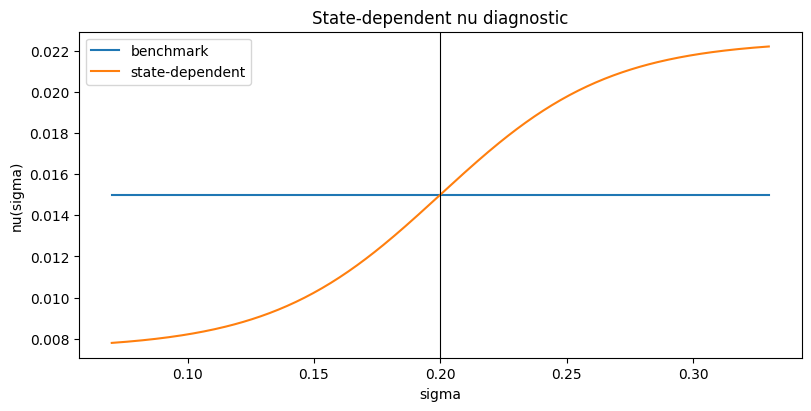

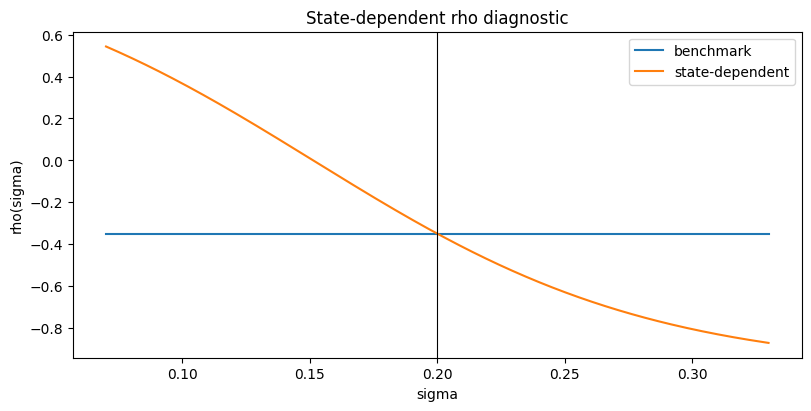

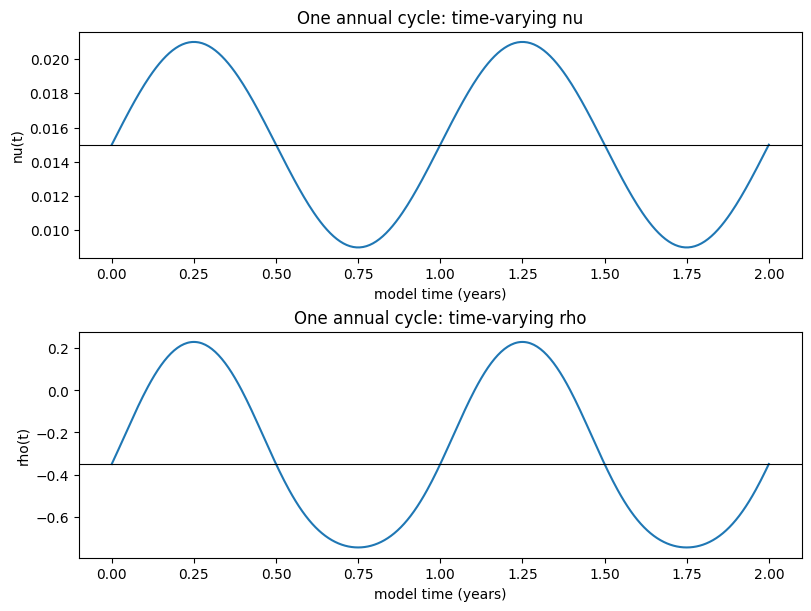

In [4]:
model_params = benchmark_case['model']
theta = float(model_params['theta'])
state_grid = np.linspace(0.35 * theta, 1.65 * theta, 301)
time_grid_diagnostic = np.linspace(0.0, benchmark_case['simulation']['years'], 401)
empty_returns = np.array([], dtype=float)

alpha_benchmark_values = np.array([alpha_fn(0.0, 100.0, sigma, empty_returns, model_params) for sigma in state_grid])
alpha_bounded_values = np.array([alpha_bounded_nonlinear(0.0, 100.0, sigma, empty_returns, model_params) for sigma in state_grid])
alpha_superlinear_values = np.array([alpha_superlinear(0.0, 100.0, sigma, empty_returns, model_params) for sigma in state_grid])
nu_benchmark_values = np.array([nu_fn(0.0, 100.0, sigma, empty_returns, model_params) for sigma in state_grid])
nu_state_values = np.array([nu_state_dependent(0.0, 100.0, sigma, empty_returns, model_params) for sigma in state_grid])
rho_benchmark_values = np.array([rho_fn(0.0, 100.0, sigma, empty_returns, model_params) for sigma in state_grid])
rho_state_values = np.array([rho_state_dependent(0.0, 100.0, sigma, empty_returns, model_params) for sigma in state_grid])
nu_time_values = np.array([nu_time_varying(t, 100.0, theta, empty_returns, model_params) for t in time_grid_diagnostic])
rho_time_values = np.array([rho_time_varying(t, 100.0, theta, empty_returns, model_params) for t in time_grid_diagnostic])

all_function_values = [alpha_benchmark_values, alpha_bounded_values, alpha_superlinear_values, nu_benchmark_values, nu_state_values, rho_benchmark_values, rho_state_values, nu_time_values, rho_time_values]
assert all(np.isfinite(values).all() for values in all_function_values)
assert (nu_state_values > 0).all() and (nu_time_values > 0).all()
assert ((rho_state_values > -1) & (rho_state_values < 1)).all()
assert ((rho_time_values > -1) & (rho_time_values < 1)).all()
assert np.isclose(alpha_bounded_nonlinear(0.0, 100.0, theta, empty_returns, model_params), 0.0)
assert np.isclose(alpha_superlinear(0.0, 100.0, theta, empty_returns, model_params), 0.0)
assert np.isclose(nu_state_dependent(0.0, 100.0, theta, empty_returns, model_params), model_params['nu_0'])
assert np.isclose(rho_state_dependent(0.0, 100.0, theta, empty_returns, model_params), model_params['rho_0'])
assert np.isclose(nu_time_varying(0.0, 100.0, theta, empty_returns, model_params), model_params['nu_0'])
assert np.isclose(rho_time_varying(0.0, 100.0, theta, empty_returns, model_params), model_params['rho_0'])
assert np.max(np.abs(alpha_bounded_values - alpha_benchmark_values)) > 1e-6
assert np.max(np.abs(alpha_superlinear_values - alpha_benchmark_values)) > 1e-6
assert np.max(np.abs(nu_state_values - nu_benchmark_values)) > 1e-6
assert np.max(np.abs(rho_state_values - rho_benchmark_values)) > 1e-6
assert np.ptp(nu_time_values) > 1e-6 and np.ptp(rho_time_values) > 1e-6

fig, axis = plt.subplots(figsize=(8, 4), constrained_layout=True)
axis.plot(state_grid, alpha_benchmark_values, label='benchmark')
axis.plot(state_grid, alpha_bounded_values, label='bounded nonlinear')
axis.plot(state_grid, alpha_superlinear_values, label='superlinear')
axis.axvline(theta, color='black', linewidth=0.8)
axis.set(xlabel='sigma', ylabel='alpha(sigma)', title='Alpha functional diagnostics')
axis.legend(); plt.show()

fig, axis = plt.subplots(figsize=(8, 4), constrained_layout=True)
axis.plot(state_grid, nu_benchmark_values, label='benchmark')
axis.plot(state_grid, nu_state_values, label='state-dependent')
axis.axvline(theta, color='black', linewidth=0.8)
axis.set(xlabel='sigma', ylabel='nu(sigma)', title='State-dependent nu diagnostic')
axis.legend(); plt.show()

fig, axis = plt.subplots(figsize=(8, 4), constrained_layout=True)
axis.plot(state_grid, rho_benchmark_values, label='benchmark')
axis.plot(state_grid, rho_state_values, label='state-dependent')
axis.axvline(theta, color='black', linewidth=0.8)
axis.set(xlabel='sigma', ylabel='rho(sigma)', title='State-dependent rho diagnostic')
axis.legend(); plt.show()

fig, axes = plt.subplots(2, 1, figsize=(8, 6), constrained_layout=True)
axes[0].plot(time_grid_diagnostic, nu_time_values); axes[0].axhline(model_params['nu_0'], color='black', linewidth=0.8)
axes[0].set(xlabel='model time (years)', ylabel='nu(t)', title='One annual cycle: time-varying nu')
axes[1].plot(time_grid_diagnostic, rho_time_values); axes[1].axhline(model_params['rho_0'], color='black', linewidth=0.8)
axes[1].set(xlabel='model time (years)', ylabel='rho(t)', title='One annual cycle: time-varying rho')
plt.show()

## 5. Nine-case registry

Only the function(s) that differ are passed as partial overrides. Scalar parameters, event schedule, response horizon, state power, estimator, and interval construction remain inherited from the benchmark.

In [5]:
case_registry = [
    {'case_name': 'benchmark', 'description': 'frozen benchmark functions', 'functions': {}},
    {'case_name': 'alpha_bounded', 'description': 'bounded nonlinear alpha', 'functions': {'alpha_fn': alpha_bounded_nonlinear}},
    {'case_name': 'alpha_superlinear', 'description': 'superlinear alpha', 'functions': {'alpha_fn': alpha_superlinear}},
    {'case_name': 'nu_state_dependent', 'description': 'state-dependent nu', 'functions': {'nu_fn': nu_state_dependent}},
    {'case_name': 'nu_time_varying', 'description': 'time-varying nu', 'functions': {'nu_fn': nu_time_varying}},
    {'case_name': 'rho_state_dependent', 'description': 'state-dependent rho', 'functions': {'rho_fn': rho_state_dependent}},
    {'case_name': 'rho_time_varying', 'description': 'time-varying rho', 'functions': {'rho_fn': rho_time_varying}},
    {'case_name': 'mixed_state_dependent', 'description': 'bounded alpha, state nu, state rho', 'functions': {'alpha_fn': alpha_bounded_nonlinear, 'nu_fn': nu_state_dependent, 'rho_fn': rho_state_dependent}},
    {'case_name': 'mixed_time_and_state', 'description': 'superlinear alpha, time nu, time rho', 'functions': {'alpha_fn': alpha_superlinear, 'nu_fn': nu_time_varying, 'rho_fn': rho_time_varying}},
]
assert [case['case_name'] for case in case_registry] == ['benchmark','alpha_bounded','alpha_superlinear','nu_state_dependent','nu_time_varying','rho_state_dependent','rho_time_varying','mixed_state_dependent','mixed_time_and_state']
assert all(set(case['functions']).issubset({'alpha_fn','nu_fn','rho_fn'}) for case in case_registry)
case_registry_table = pd.DataFrame([{key: value for key, value in case.items() if key != 'functions'} for case in case_registry])
display(case_registry_table)

,case_name,description
0,benchmark,frozen benchmark functions
1,alpha_bounded,bounded nonlinear alpha
2,alpha_superlinear,superlinear alpha
3,nu_state_dependent,state-dependent nu
4,nu_time_varying,time-varying nu
5,rho_state_dependent,state-dependent rho
6,rho_time_varying,time-varying rho
7,mixed_state_dependent,"bounded alpha, state nu, state rho"
8,mixed_time_and_state,"superlinear alpha, time nu, time rho"


## 6. Benchmark reproduction

The benchmark is run first without overrides. It is reproduced with the same shock bank before alternatives are considered; this confirms that the frozen workflow remains callable and deterministic in this notebook.

In [6]:
benchmark_result = run_full_pipeline(
    benchmark_case,
    shock_bank=common_shock_bank,
    include_causality=True,
    include_intervals=True,
    include_truth=False,
    functions=None,
)
benchmark_repeat = run_full_pipeline(
    benchmark_case,
    shock_bank=common_shock_bank,
    include_causality=True,
    include_intervals=True,
    include_truth=False,
    functions=None,
)
benchmark_summary = summarise_case(benchmark_result)
repeat_summary = summarise_case(benchmark_repeat)

assert benchmark_result['truth'] is None
assert benchmark_result['config']['model']['n'] == 1
assert benchmark_result['simulation']['states'][['S','sigma','x']].gt(0).all().all()
assert benchmark_result['simulation']['transitions'][['F','x_next','sigma_next','omega_next']].gt(0).all().all()
assert benchmark_summary['training_count'] == repeat_summary['training_count']
assert benchmark_summary['testing_count'] == repeat_summary['testing_count']
assert np.isclose(benchmark_summary['A_hat'], repeat_summary['A_hat'])
assert np.isclose(benchmark_summary['lambda_hat'], repeat_summary['lambda_hat'])
assert np.isclose(benchmark_summary['active_sigma_parametric_MAE'], repeat_summary['active_sigma_parametric_MAE'])
frozen_benchmark_reference_passed = (
    np.isclose(benchmark_summary['A_hat'], 0.008406, rtol=0.02, atol=1e-6)
    and np.isclose(benchmark_summary['lambda_hat'], 36.09, rtol=0.03, atol=0.05)
    and np.isclose(benchmark_summary['active_sigma_parametric_MAE_gain_pct'], 26.86, atol=1.0)
)
assert frozen_benchmark_reference_passed
print('Benchmark reproduction passed with the frozen common-shock workflow and Notebook 06 reference tolerances.')

Benchmark reproduction passed with the frozen common-shock workflow and Notebook 06 reference tolerances.


## 7. Run the nine cases with paired shocks

Every case uses the same benchmark configuration and shock bank. Failures are deliberately not swallowed: an invalid state or failed assertion stops the notebook rather than being silently converted into a result row.

In [7]:
case_results = {'benchmark': benchmark_result}
for case in case_registry[1:]:
    case_config = make_case_config(reference_config, label=case['case_name'])
    case_results[case['case_name']] = run_full_pipeline(
        case_config,
        shock_bank=common_shock_bank,
        include_causality=True,
        include_intervals=True,
        include_truth=False,
        functions=case['functions'],
    )

assert set(case_results) == set(case_registry_table['case_name'])
assert all(result['truth'] is None for result in case_results.values())
assert all(result['config']['model']['n'] == 1 for result in case_results.values())
assert all(np.array_equal(result['simulation']['transitions']['epsilon'], benchmark_result['simulation']['transitions']['epsilon']) for result in case_results.values())
assert all(np.array_equal(result['simulation']['transitions']['eta'], benchmark_result['simulation']['transitions']['eta']) for result in case_results.values())
assert all(result['simulation']['states'][['S','sigma','x']].gt(0).all().all() for result in case_results.values())
print(f'Completed {len(case_results)} paired common-shock cases.')

Completed 9 paired common-shock cases.


## 8. Causality and information diagnostics across functionals

The frozen Notebook 06 methodology is applied to every functional case, producing three distinct diagnostics:

1. **Historical Granger causality**: a lagged linear predictive test using historical target and event lags.
2. **Conditional predictive structure**: the separate conditional OLS event-history test, which is not labelled as Granger causality.
3. **Time-delayed mutual information (TDMI)**: a direct contingency-table dependence measure.

Unrestricted TDMI global peaks can be affected by state persistence and periodic event-calendar aliases. The direct-response window is the main structurally relevant comparison.

Historical Granger causality


,case_name,target,direction,lag_order,F_statistic,p_value,partial_R_squared,sample_size,significant_5pct
0,benchmark,powered-state level,event history -> target,13,3.9495,4.061e-06,0.102005,479,True
1,benchmark,powered-state change,event history -> target,13,3.8717,5.837e-06,0.100397,478,True
2,alpha_bounded,powered-state level,event history -> target,13,4.0049,3.138e-06,0.103289,479,True
3,alpha_bounded,powered-state change,event history -> target,13,3.8997,5.127e-06,0.101050,478,True
4,alpha_superlinear,powered-state level,event history -> target,13,3.8875,5.417e-06,0.100564,479,True
5,alpha_superlinear,powered-state change,event history -> target,13,3.8401,6.758e-06,0.099658,478,True
6,nu_state_dependent,powered-state level,event history -> target,13,3.0448,2.490e-04,0.080521,479,True
7,nu_state_dependent,powered-state change,event history -> target,13,2.9774,3.355e-04,0.079040,478,True
8,nu_time_varying,powered-state level,event history -> target,13,3.3809,5.530e-05,0.088620,479,True
9,nu_time_varying,powered-state change,event history -> target,13,3.2896,8.359e-05,0.086610,478,True


Conditional predictive structure


,case_name,target,direction,F_statistic,p_value,partial_r_squared,nobs
0,benchmark,state_next,event history -> target,3.2508,1.186e-04,0.113828,345
1,benchmark,delta_state_next,event history -> target,3.2508,1.186e-04,0.113828,345
2,alpha_bounded,state_next,event history -> target,3.2695,1.093e-04,0.114409,345
3,alpha_bounded,delta_state_next,event history -> target,3.2695,1.093e-04,0.114409,345
4,alpha_superlinear,state_next,event history -> target,3.2266,1.317e-04,0.113078,345
5,alpha_superlinear,delta_state_next,event history -> target,3.2266,1.317e-04,0.113078,345
6,nu_state_dependent,state_next,event history -> target,2.3496,5.215e-03,0.084954,345
7,nu_state_dependent,delta_state_next,event history -> target,2.3496,5.215e-03,0.084954,345
8,nu_time_varying,state_next,event history -> target,2.5316,2.499e-03,0.090935,345
9,nu_time_varying,delta_state_next,event history -> target,2.5316,2.499e-03,0.090935,345


Time-delayed mutual information summaries


,case_name,target,direct_response_peak,direct_response_lag,first_cycle_peak,first_cycle_lag,global_peak,global_peak_lag
0,benchmark,level,0.010993,8,0.010993,8,0.010993,8
1,benchmark,change,0.024192,1,0.024192,1,0.024620,-20
2,alpha_bounded,level,0.009868,8,0.009868,8,0.010316,-15
3,alpha_bounded,change,0.023764,1,0.023764,1,0.023764,1
4,alpha_superlinear,level,0.011323,6,0.011323,6,0.011522,-15
5,alpha_superlinear,change,0.023810,1,0.023810,1,0.023810,1
6,nu_state_dependent,level,0.009503,6,0.009503,6,0.009873,-15
7,nu_state_dependent,change,0.023837,9,0.023837,9,0.023837,9
8,nu_time_varying,level,0.013080,9,0.013080,9,0.013157,-12
9,nu_time_varying,change,0.028019,1,0.028019,1,0.028019,1


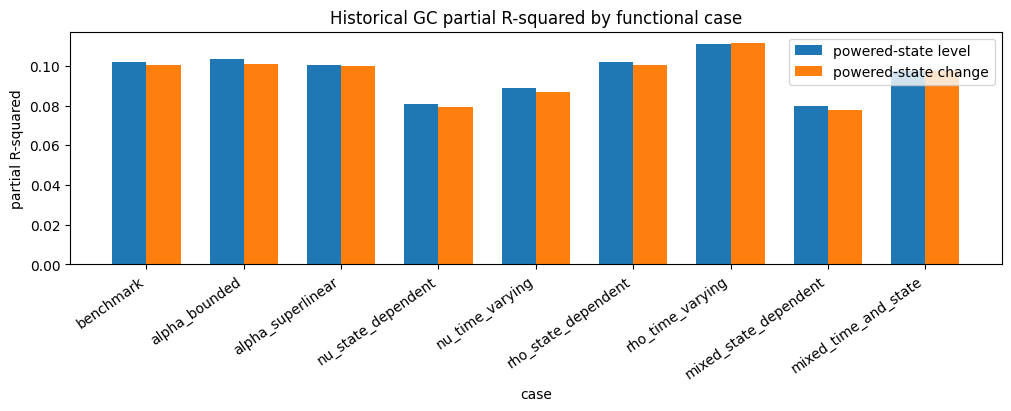

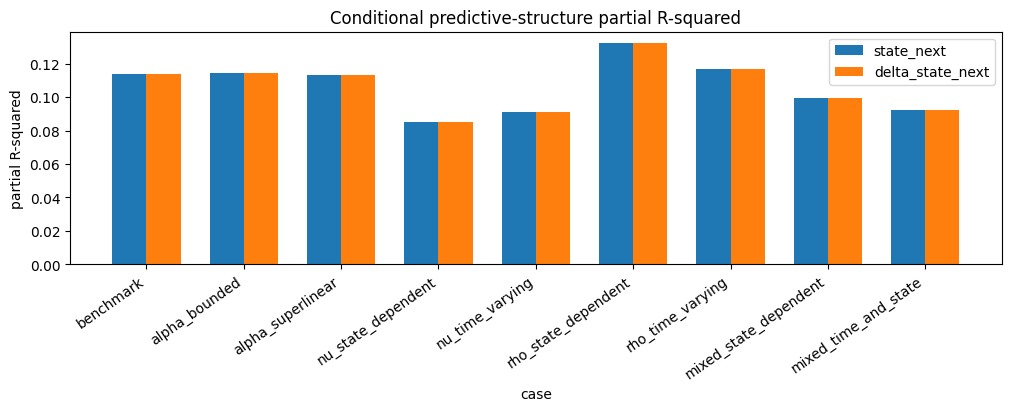

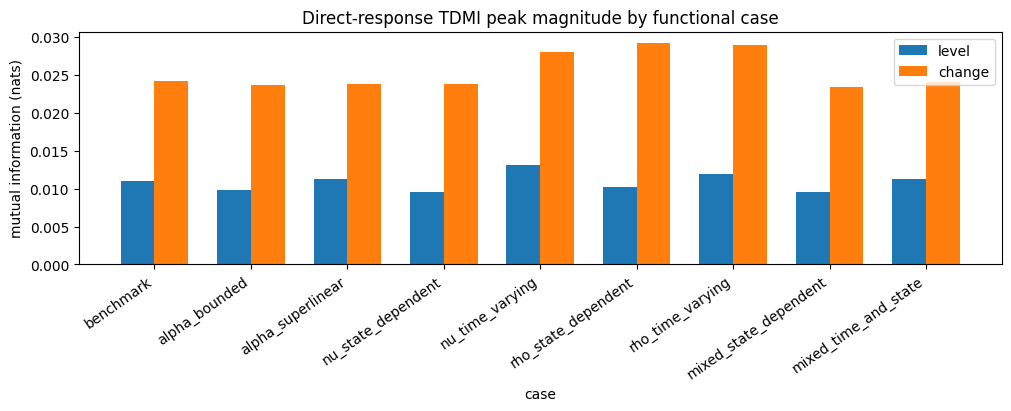

In [8]:
historical_gc_rows = []
conditional_structure_rows = []
tdmi_rows = []
for case_name, result in case_results.items():
    gc_table = result['causality']['gc'].copy()
    gc_table.insert(0, 'case_name', case_name)
    historical_gc_rows.append(gc_table[[
        'case_name', 'target', 'direction', 'lag_order', 'F_statistic', 'p_value',
        'partial_R_squared', 'sample_size', 'significant_5pct',
    ]])

    structure_table = result['causality']['conditional_structure'].copy()
    structure_table.insert(0, 'case_name', case_name)
    available_structure_columns = [
        column for column in [
            'case_name', 'target', 'direction', 'F_statistic', 'p_value',
            'partial_r_squared', 'nobs',
        ] if column in structure_table.columns
    ]
    conditional_structure_rows.append(structure_table[available_structure_columns])

    tdmi_table = result['causality']['tdmi_summary'].copy()
    tdmi_table.insert(0, 'case_name', case_name)
    tdmi_rows.append(tdmi_table[[
        'case_name', 'target', 'direct_response_peak', 'direct_response_lag',
        'first_cycle_peak', 'first_cycle_lag', 'global_peak', 'global_peak_lag',
    ]])

historical_gc_table = pd.concat(historical_gc_rows, ignore_index=True)
conditional_predictive_structure_table = pd.concat(conditional_structure_rows, ignore_index=True)
tdmi_functional_table = pd.concat(tdmi_rows, ignore_index=True)

assert len(historical_gc_table) == 2 * len(case_results)
assert len(conditional_predictive_structure_table) == 2 * len(case_results)
assert len(tdmi_functional_table) == 2 * len(case_results)
assert set(historical_gc_table['target']) == {'powered-state level', 'powered-state change'}
assert set(conditional_predictive_structure_table['target']) == {'state_next', 'delta_state_next'}
assert set(tdmi_functional_table['target']) == {'level', 'change'}
assert historical_gc_table['p_value'].between(0, 1).all()
assert conditional_predictive_structure_table['p_value'].between(0, 1).all()

print('Historical Granger causality')
display(historical_gc_table.style.format({'p_value': '{:.3e}', 'F_statistic': '{:.4f}', 'partial_R_squared': '{:.6f}'}))
print('Conditional predictive structure')
display(conditional_predictive_structure_table.style.format({'p_value': '{:.3e}', 'F_statistic': '{:.4f}', 'partial_r_squared': '{:.6f}'}))
print('Time-delayed mutual information summaries')
display(tdmi_functional_table.style.format({'direct_response_peak': '{:.6f}', 'first_cycle_peak': '{:.6f}', 'global_peak': '{:.6f}'}))

def grouped_case_bar(table, target_column, value_column, title, ylabel):
    case_order = [case['case_name'] for case in case_registry]
    targets = list(table[target_column].unique())
    positions = np.arange(len(case_order))
    width = 0.7 / len(targets)
    fig, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
    for number, target in enumerate(targets):
        subset = table.loc[table[target_column].eq(target)].set_index('case_name').reindex(case_order)
        offset = (number - (len(targets) - 1) / 2) * width
        axis.bar(positions + offset, subset[value_column], width, label=target)
    axis.set(title=title, xlabel='case', ylabel=ylabel)
    axis.set_xticks(positions, case_order, rotation=35, ha='right')
    axis.legend()
    plt.show()

grouped_case_bar(historical_gc_table, 'target', 'partial_R_squared', 'Historical GC partial R-squared by functional case', 'partial R-squared')
grouped_case_bar(conditional_predictive_structure_table, 'target', 'partial_r_squared', 'Conditional predictive-structure partial R-squared', 'partial R-squared')
grouped_case_bar(tdmi_functional_table, 'target', 'direct_response_peak', 'Direct-response TDMI peak magnitude by functional case', 'mutual information (nats)')

### Full signed-lag TDMI curves

The following plots retain the complete signed-lag TDMI curves, including negative lags. The orange band is the inherited direct-response window, derived as $+1$ through $+(h+1)$; for this benchmark it is $+1$ through $+13$. Markers identify each case's direct-window peak. Axes are held common across all level plots and separately across all change plots.

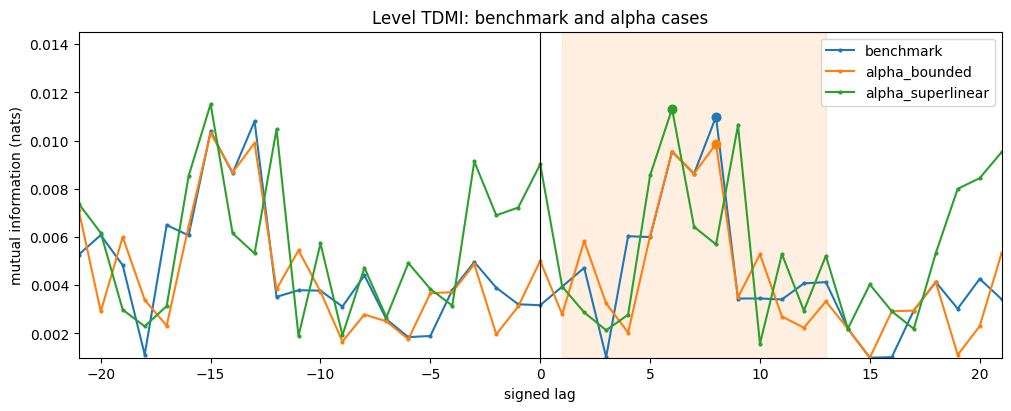

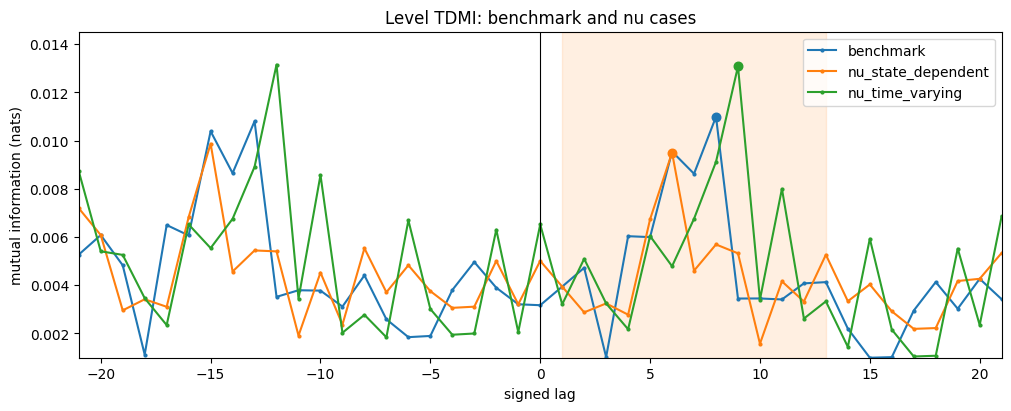

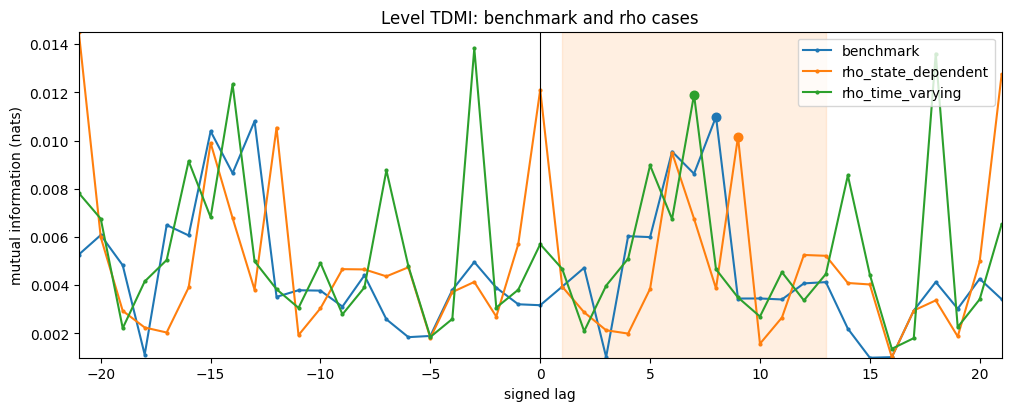

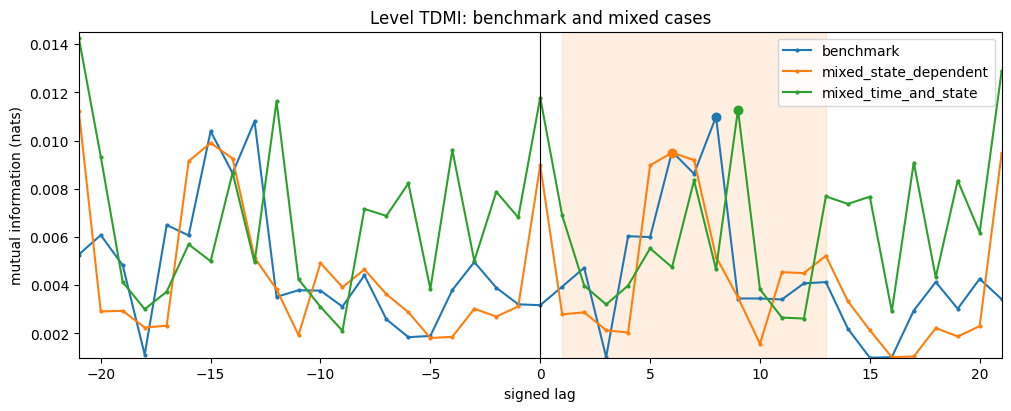

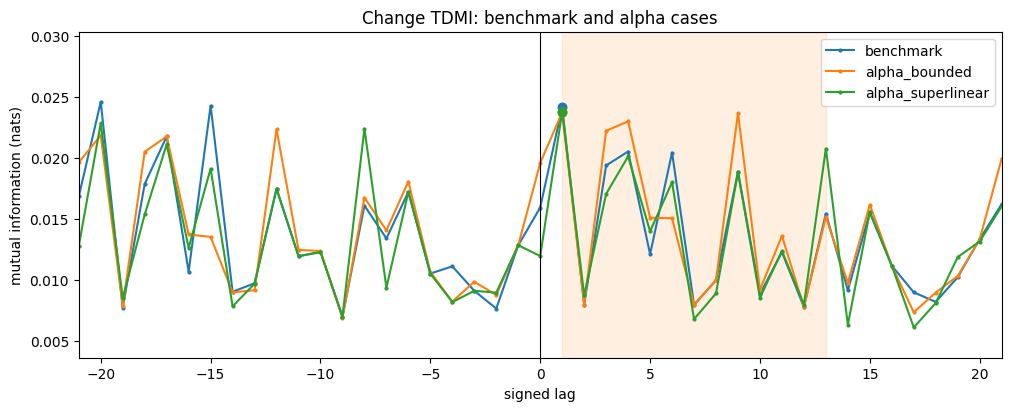

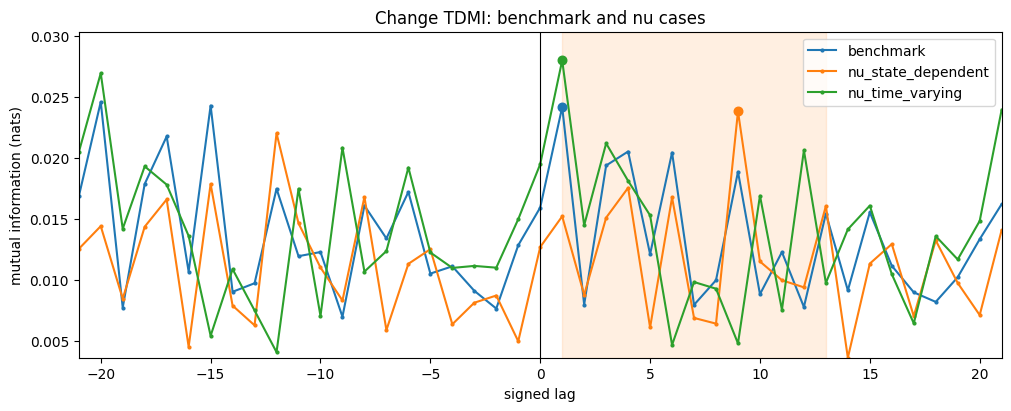

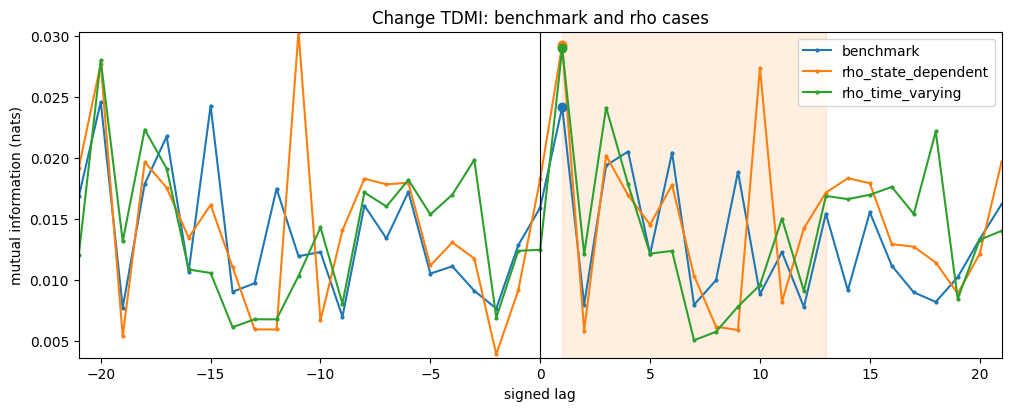

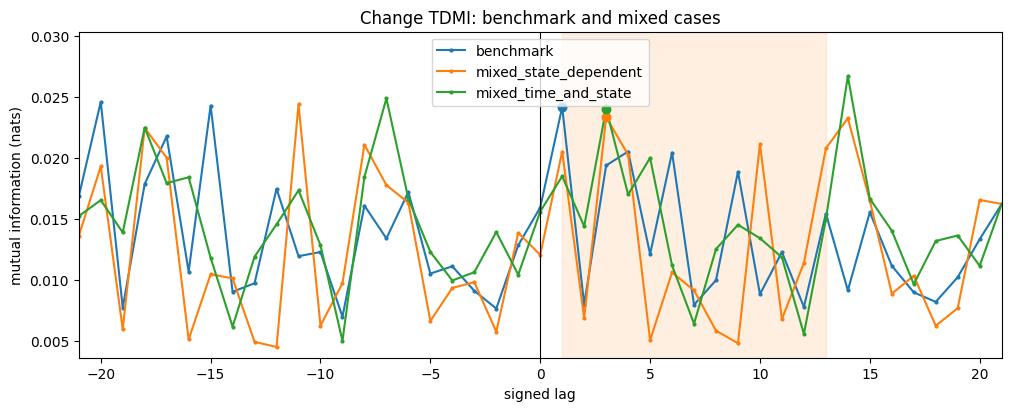

In [9]:
direct_window_start = 1
direct_window_end = benchmark_result['timing']['response_horizon_steps'] + 1
tdmi_groups = [
    (['benchmark', 'alpha_bounded', 'alpha_superlinear'], 'benchmark and alpha cases'),
    (['benchmark', 'nu_state_dependent', 'nu_time_varying'], 'benchmark and nu cases'),
    (['benchmark', 'rho_state_dependent', 'rho_time_varying'], 'benchmark and rho cases'),
    (['benchmark', 'mixed_state_dependent', 'mixed_time_and_state'], 'benchmark and mixed cases'),
]

level_curves = {name: result['causality']['tdmi_level_curve'].copy() for name, result in case_results.items()}
change_curves = {name: result['causality']['tdmi_change_curve'].copy() for name, result in case_results.items()}
reference_level_lags = level_curves['benchmark']['lag'].to_numpy()
reference_change_lags = change_curves['benchmark']['lag'].to_numpy()
assert all(np.array_equal(curve['lag'].to_numpy(), reference_level_lags) for curve in level_curves.values())
assert all(np.array_equal(curve['lag'].to_numpy(), reference_change_lags) for curve in change_curves.values())
assert set(range(direct_window_start, direct_window_end + 1)).issubset(set(reference_level_lags))
assert set(range(direct_window_start, direct_window_end + 1)).issubset(set(reference_change_lags))

level_ylim = (
    min(curve['mutual_information'].min() for curve in level_curves.values()),
    max(curve['mutual_information'].max() for curve in level_curves.values()),
)
change_ylim = (
    min(curve['mutual_information'].min() for curve in change_curves.values()),
    max(curve['mutual_information'].max() for curve in change_curves.values()),
)
level_xlim = (int(reference_level_lags.min()), int(reference_level_lags.max()))
change_xlim = (int(reference_change_lags.min()), int(reference_change_lags.max()))

def plot_tdmi_group(case_names, target, title, curves, xlim, ylim):
    fig, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
    for case_name in case_names:
        curve = curves[case_name]
        axis.plot(curve['lag'], curve['mutual_information'], marker='o', markersize=2, label=case_name)
        summary = case_results[case_name]['causality']['tdmi_summary']
        peak = summary.loc[summary['target'].eq(target)].iloc[0]
        axis.scatter(peak['direct_response_lag'], peak['direct_response_peak'], s=38, zorder=3)
    axis.axvline(0, color='black', linewidth=0.8)
    axis.axvspan(direct_window_start, direct_window_end, color='tab:orange', alpha=0.12)
    axis.set(title=title, xlabel='signed lag', ylabel='mutual information (nats)', xlim=xlim, ylim=ylim)
    axis.legend()
    plt.show()

for case_names, group_name in tdmi_groups:
    plot_tdmi_group(case_names, 'level', f'Level TDMI: {group_name}', level_curves, level_xlim, level_ylim)
for case_names, group_name in tdmi_groups:
    plot_tdmi_group(case_names, 'change', f'Change TDMI: {group_name}', change_curves, change_xlim, change_ylim)

### Historical GC lag-order sensitivity

The frozen Notebook 06 historical-GC result at its validated lag order remains the primary result. This sensitivity diagnostic re-estimates the same nested autoregressive specification at $p=1,2,\ldots,13$ for each case and target.

A point at order $p$ jointly tests event lags $1$ through $p$; it is **not** an estimate that the causal effect occurs specifically at lag $p$. All designs are trimmed to the observations available at $p=13$, so changes across the profile are not confounded with effective sample size.

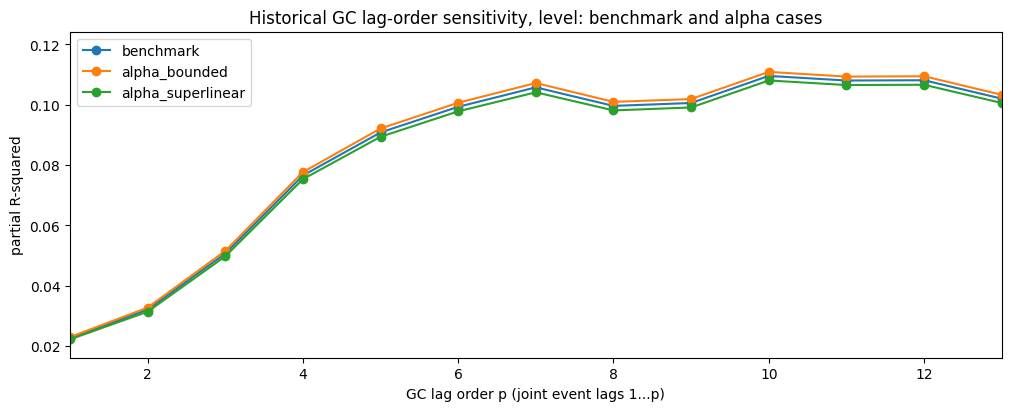

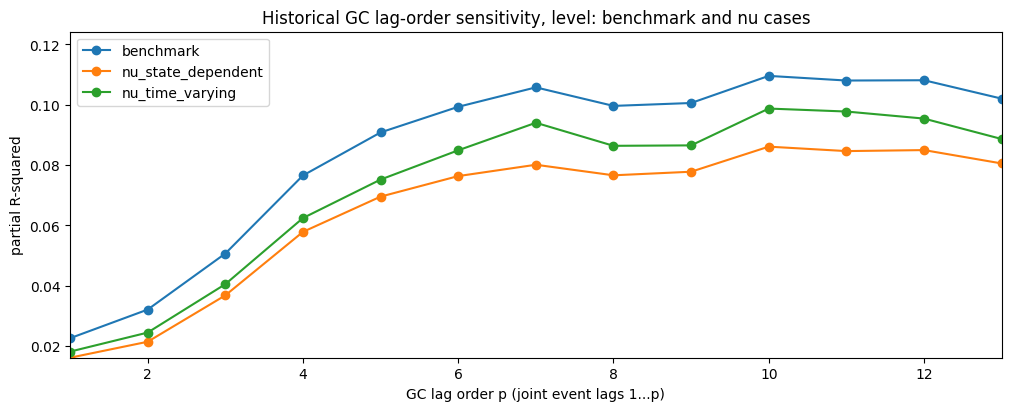

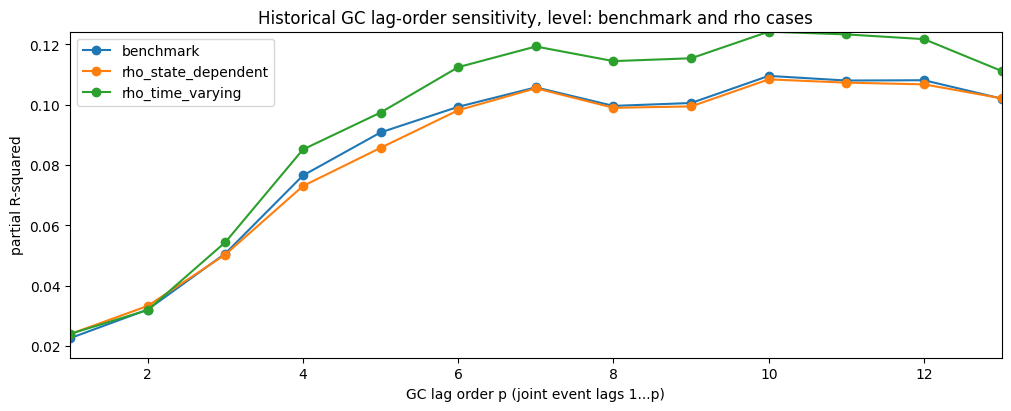

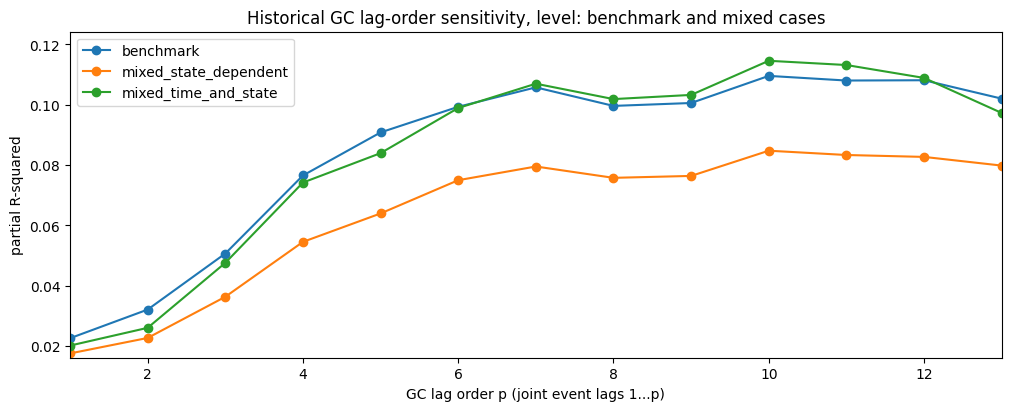

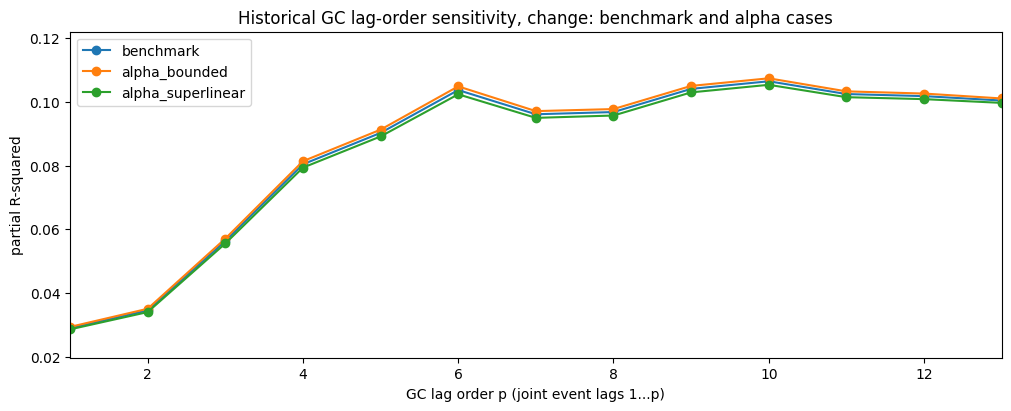

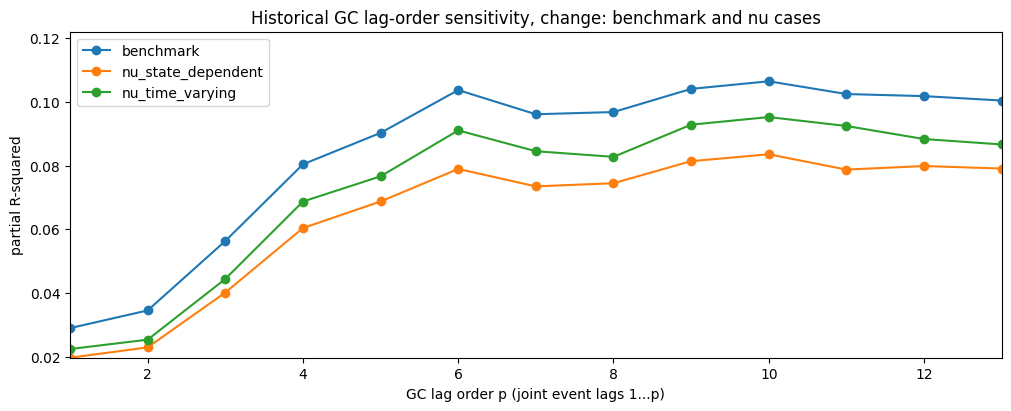

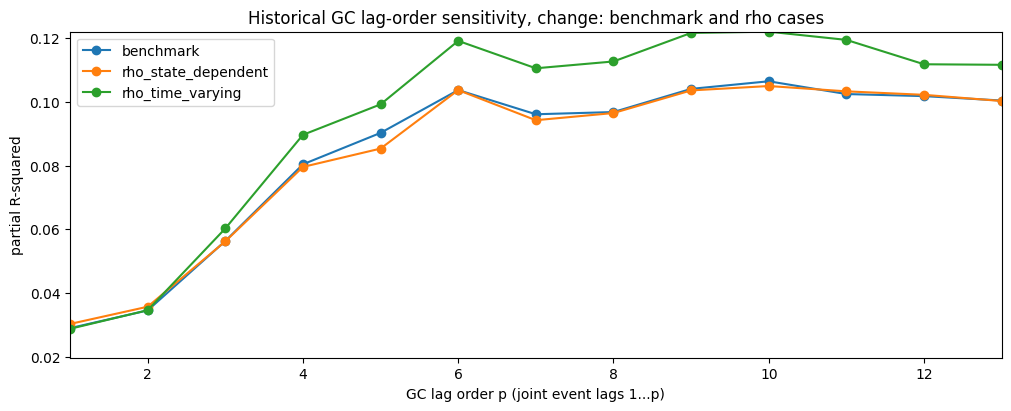

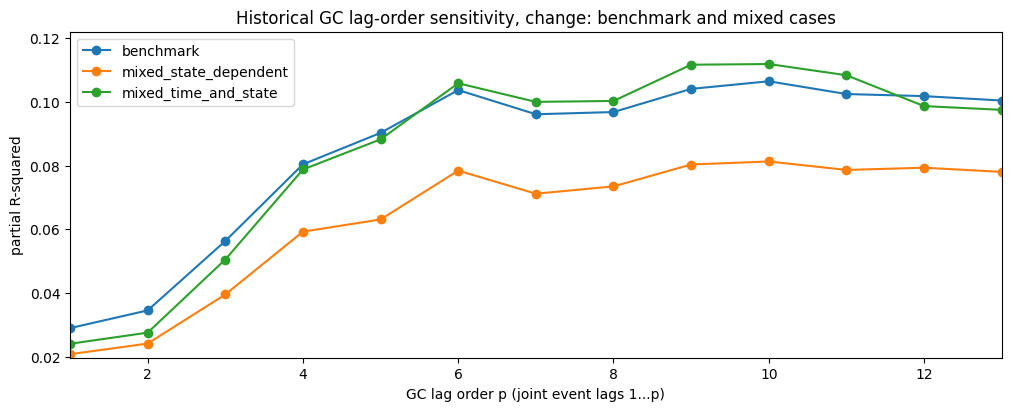

In [10]:
maximum_gc_order = direct_window_end
lag_sensitivity_rows = []
for case_name, result in case_results.items():
    transition_table = result['transition_table']
    event = transition_table['event_i'].to_numpy(dtype=float)
    level = transition_table['state_i'].to_numpy(dtype=float)
    change = np.diff(level)
    change_event = event[1:]
    for order in range(1, maximum_gc_order + 1):
        trim_start = maximum_gc_order - order
        level_result, _ = _historical_gc(
            level[trim_start:], event[trim_start:], order,
            'powered-state level', 'state_i',
        )
        change_result, _ = _historical_gc(
            change[trim_start:], change_event[trim_start:], order,
            'powered-state change', 'delta_state_i',
        )
        for row in [level_result, change_result]:
            lag_sensitivity_rows.append({'case_name': case_name, **row})

historical_gc_lag_sensitivity = pd.DataFrame(lag_sensitivity_rows)
assert set(historical_gc_lag_sensitivity['lag_order']) == set(range(1, maximum_gc_order + 1))
assert set(historical_gc_lag_sensitivity['target']) == {'powered-state level', 'powered-state change'}
assert historical_gc_lag_sensitivity['partial_R_squared'].between(0, 1).all()
assert historical_gc_lag_sensitivity['p_value'].between(0, 1).all()
assert all(
    subset['sample_size'].nunique() == 1
    for _, subset in historical_gc_lag_sensitivity.groupby(['case_name', 'target'])
)

gc_groups = tdmi_groups
level_gc_ylim = (
    historical_gc_lag_sensitivity.loc[historical_gc_lag_sensitivity['target'].eq('powered-state level'), 'partial_R_squared'].min(),
    historical_gc_lag_sensitivity.loc[historical_gc_lag_sensitivity['target'].eq('powered-state level'), 'partial_R_squared'].max(),
)
change_gc_ylim = (
    historical_gc_lag_sensitivity.loc[historical_gc_lag_sensitivity['target'].eq('powered-state change'), 'partial_R_squared'].min(),
    historical_gc_lag_sensitivity.loc[historical_gc_lag_sensitivity['target'].eq('powered-state change'), 'partial_R_squared'].max(),
)

def plot_gc_lag_sensitivity(case_names, target, title, ylim):
    fig, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
    for case_name in case_names:
        subset = historical_gc_lag_sensitivity.loc[
            historical_gc_lag_sensitivity['case_name'].eq(case_name)
            & historical_gc_lag_sensitivity['target'].eq(target)
        ]
        axis.plot(subset['lag_order'], subset['partial_R_squared'], marker='o', label=case_name)
    axis.set(title=title, xlabel='GC lag order p (joint event lags 1...p)', ylabel='partial R-squared', xlim=(1, maximum_gc_order), ylim=ylim)
    axis.legend()
    plt.show()

for case_names, group_name in gc_groups:
    plot_gc_lag_sensitivity(case_names, 'powered-state level', f'Historical GC lag-order sensitivity, level: {group_name}', level_gc_ylim)
for case_names, group_name in gc_groups:
    plot_gc_lag_sensitivity(case_names, 'powered-state change', f'Historical GC lag-order sensitivity, change: {group_name}', change_gc_ylim)

## 9. Evaluation-only event-profile recovery and event-age forecast diagnostics

All fitting and frozen one-step forecasts have now been completed.  Only at this evaluation stage, the synthetic event multiplier is reconstructed from the known simulator state for comparison with the fitted parametric and non-parametric multipliers.  The multiplier shown is the factor applied to powered state $X$, rather than $\omega$.

Event-age forecast summaries retain only complete test response cycles: each included cycle has every configured transition age exactly once.  These small, dependent within-cycle summaries are diagnostic, not separate hypothesis tests.

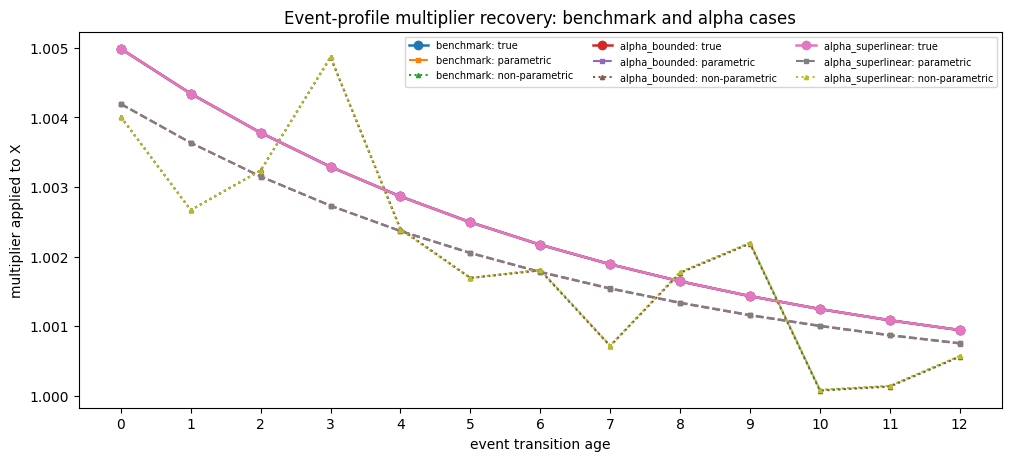

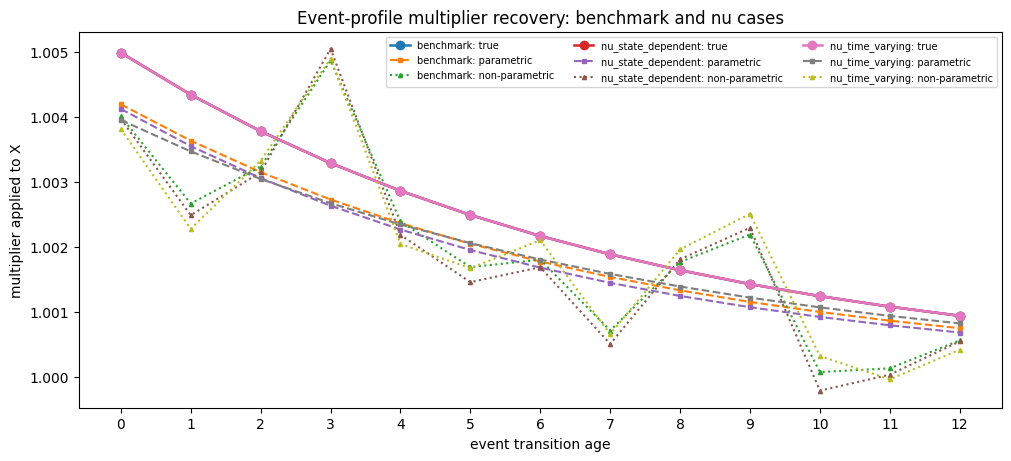

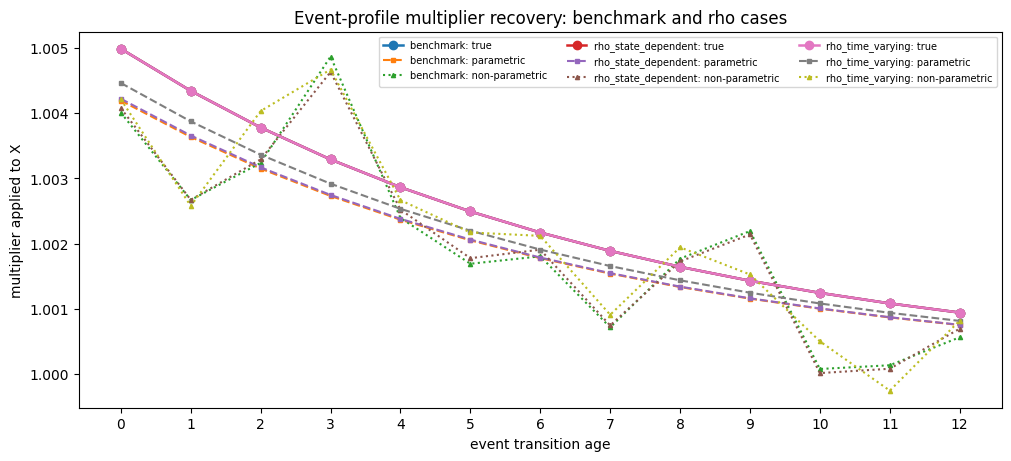

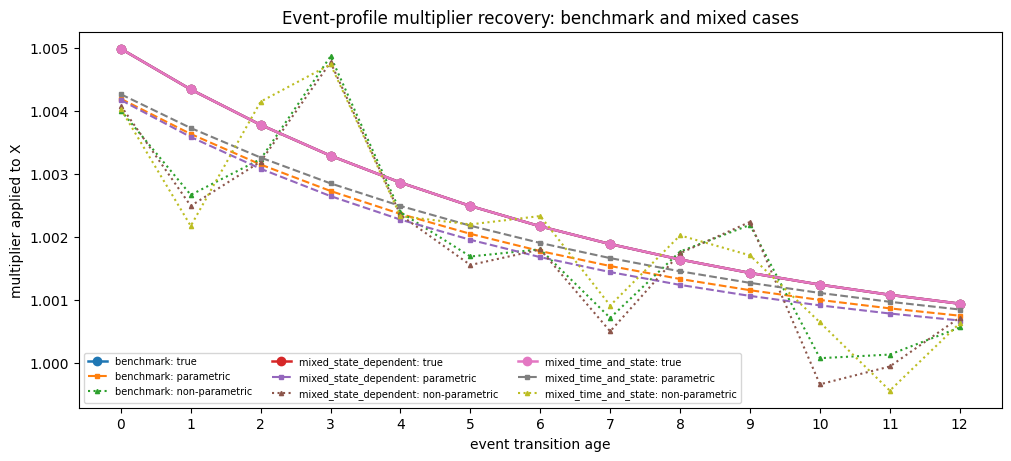

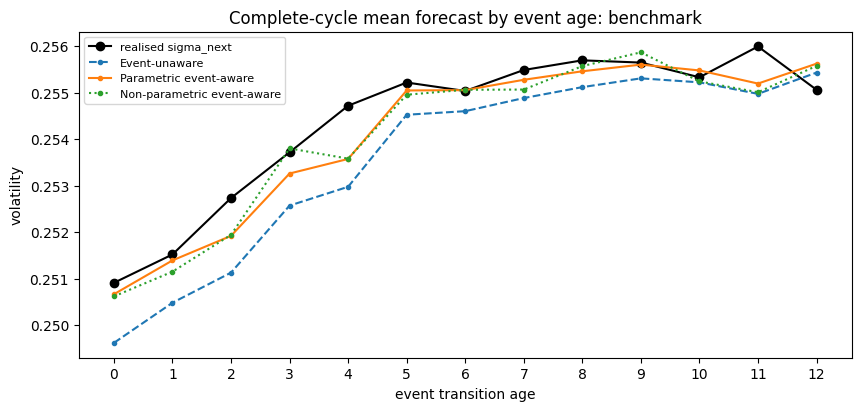

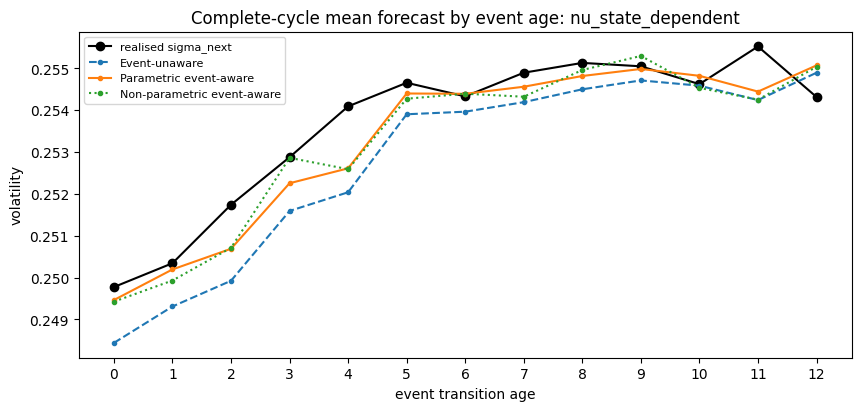

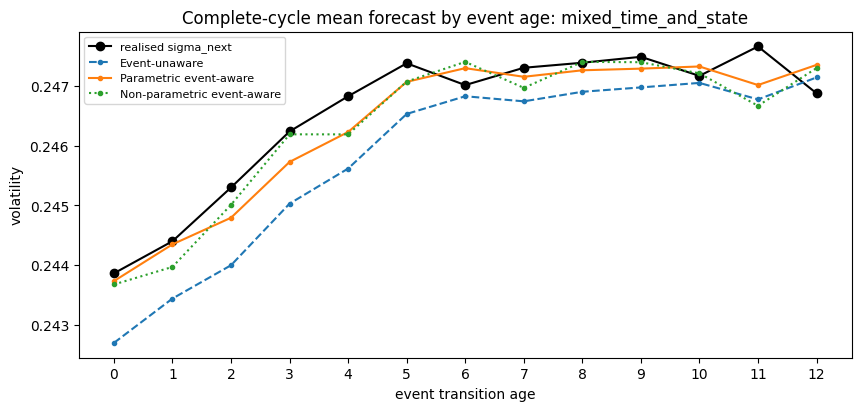

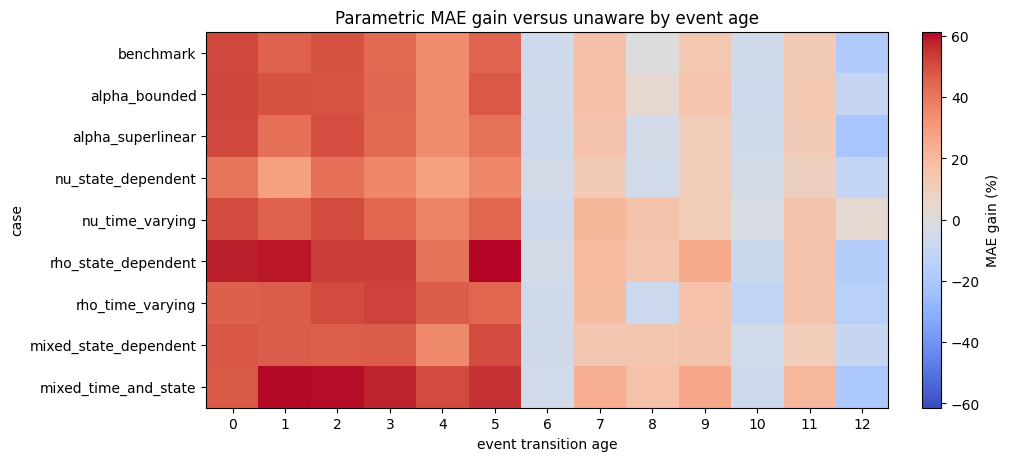

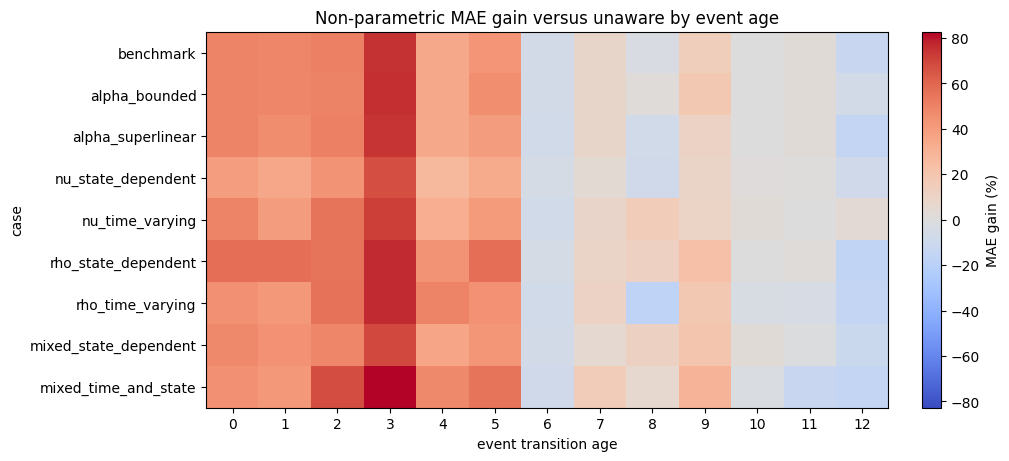

,case_name,event_age,true_multiplier,parametric_multiplier,nonparametric_multiplier
0,benchmark,0,1.004988,1.004194,1.004008
1,benchmark,1,1.004342,1.003635,1.002670
2,benchmark,2,1.003780,1.003151,1.003238
3,benchmark,3,1.003291,1.002731,1.004868
4,benchmark,4,1.002865,1.002367,1.002394
...,...,...,...,...,...
112,mixed_time_and_state,8,1.001645,1.001457,1.002027
113,mixed_time_and_state,9,1.001431,1.001274,1.001710
114,mixed_time_and_state,10,1.001246,1.001114,1.000648
115,mixed_time_and_state,11,1.001084,1.000974,0.999565


,case_name,complete_test_cycles,complete_active_rows,all_active_test_rows
0,benchmark,7,91,91
1,alpha_bounded,7,91,91
2,alpha_superlinear,7,91,91
3,nu_state_dependent,7,91,91
4,nu_time_varying,7,91,91
5,rho_state_dependent,7,91,91
6,rho_time_varying,7,91,91
7,mixed_state_dependent,7,91,91
8,mixed_time_and_state,7,91,91


,case_name,event_age,model,observation_count,MAE,mean_sigma_next,mean_forecast
0,benchmark,0,Event-unaware,7,0.001292,0.250913,0.249621
1,benchmark,0,Parametric event-aware,7,0.000630,0.250913,0.250668
2,benchmark,0,Non-parametric event-aware,7,0.000651,0.250913,0.250621
3,benchmark,1,Event-unaware,7,0.001039,0.251523,0.250484
4,benchmark,1,Parametric event-aware,7,0.000566,0.251523,0.251395
...,...,...,...,...,...,...,...
346,mixed_time_and_state,11,Parametric event-aware,7,0.000705,0.247663,0.247017
347,mixed_time_and_state,11,Non-parametric event-aware,7,0.000994,0.247663,0.246669
348,mixed_time_and_state,12,Event-unaware,7,0.000466,0.246878,0.247144
349,mixed_time_and_state,12,Parametric event-aware,7,0.000555,0.246878,0.247354


In [11]:
event_ages = np.asarray(benchmark_result['timing']['event_transition_ages'], dtype=int)
assert np.array_equal(event_ages, np.arange(len(event_ages)))

profile_recovery_rows = []
complete_cycle_rows = []
event_age_mae_rows = []
truth_access_after_fitted_objects_frozen = True
forecast_columns = {
    'Event-unaware': 'sigma_forecast_unaware',
    'Parametric event-aware': 'sigma_forecast_parametric',
    'Non-parametric event-aware': 'sigma_forecast_nonparametric',
}

for case_name, result in case_results.items():
    truth_access_after_fitted_objects_frozen &= 'forecasts_frozen' in result['pipeline_stages']
    truth_reference = build_known_dgp_reference(result)
    truth_active = truth_reference['table'].loc[
        truth_reference['table']['event_active_i'].astype(bool), ['event_age_i', 'm_true']
    ].copy()
    truth_active['event_age_i'] = truth_active['event_age_i'].astype(int)
    true_multiplier = truth_active.groupby('event_age_i')['m_true'].mean().reindex(event_ages)
    parametric_multiplier = pd.Series(
        result['profiles']['parametric_multiplier'](event_ages), index=event_ages
    )
    nonparametric_multiplier = result['profiles']['nonparametric'].reindex(event_ages)
    profile_recovery_rows.extend([
        {'case_name': case_name, 'event_age': int(age), 'true_multiplier': true_multiplier.loc[age],
         'parametric_multiplier': parametric_multiplier.loc[age],
         'nonparametric_multiplier': nonparametric_multiplier.loc[age]}
        for age in event_ages
    ])

    active = result['evaluation']['evaluation'].loc[
        result['evaluation']['evaluation']['event_active_i'].astype(bool)
    ].copy()
    active['event_age_i'] = active['event_age_i'].astype(int)
    active['cycle_start_i'] = active['i'].astype(int) - active['event_age_i']
    complete_cycles = []
    for cycle_start, cycle in active.groupby('cycle_start_i', sort=True):
        ages = cycle['event_age_i'].to_numpy()
        if len(cycle) == len(event_ages) and np.array_equal(np.sort(ages), event_ages):
            complete_cycles.append(cycle_start)
    complete_active = active.loc[active['cycle_start_i'].isin(complete_cycles)].copy()
    complete_cycle_rows.append({
        'case_name': case_name,
        'complete_test_cycles': len(complete_cycles),
        'complete_active_rows': len(complete_active),
        'all_active_test_rows': len(active),
    })
    for age in event_ages:
        age_rows = complete_active.loc[complete_active['event_age_i'].eq(age)]
        for model, column in forecast_columns.items():
            event_age_mae_rows.append({
                'case_name': case_name,
                'event_age': int(age),
                'model': model,
                'observation_count': len(age_rows),
                'MAE': float((age_rows['sigma_next'] - age_rows[column]).abs().mean()),
                'mean_sigma_next': float(age_rows['sigma_next'].mean()),
                'mean_forecast': float(age_rows[column].mean()),
            })

profile_recovery_table = pd.DataFrame(profile_recovery_rows)
complete_cycle_summary = pd.DataFrame(complete_cycle_rows)
event_age_mae_table = pd.DataFrame(event_age_mae_rows)

for names, title in tdmi_groups:
    fig, axis = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
    for name in names:
        data = profile_recovery_table.loc[profile_recovery_table['case_name'].eq(name)]
        axis.plot(data['event_age'], data['true_multiplier'], marker='o', linewidth=1.8, label=f'{name}: true')
        axis.plot(data['event_age'], data['parametric_multiplier'], linestyle='--', marker='s', markersize=3, label=f'{name}: parametric')
        axis.plot(data['event_age'], data['nonparametric_multiplier'], linestyle=':', marker='^', markersize=3, label=f'{name}: non-parametric')
    axis.set(title=f'Event-profile multiplier recovery: {title}', xlabel='event transition age', ylabel='multiplier applied to X')
    axis.set_xticks(event_ages)
    axis.legend(ncol=3, fontsize=7)
    plt.show()

for name in ['benchmark', 'nu_state_dependent', 'mixed_time_and_state']:
    data = event_age_mae_table.loc[event_age_mae_table['case_name'].eq(name)]
    fig, axis = plt.subplots(figsize=(8.5, 4), constrained_layout=True)
    realised = data.loc[data['model'].eq('Event-unaware'), ['event_age', 'mean_sigma_next']]
    axis.plot(realised['event_age'], realised['mean_sigma_next'], color='black', marker='o', label='realised sigma_next')
    for model, style in [('Event-unaware', '--'), ('Parametric event-aware', '-'), ('Non-parametric event-aware', ':')]:
        series = data.loc[data['model'].eq(model), ['event_age', 'mean_forecast']]
        axis.plot(series['event_age'], series['mean_forecast'], linestyle=style, marker='o', markersize=3, label=model)
    axis.set(title=f'Complete-cycle mean forecast by event age: {name}', xlabel='event transition age', ylabel='volatility')
    axis.set_xticks(event_ages)
    axis.legend(fontsize=8)
    plt.show()

mae_by_age = event_age_mae_table.pivot(index=['case_name', 'event_age'], columns='model', values='MAE').reset_index()
mae_by_age['parametric_gain_pct'] = 100 * (1 - mae_by_age['Parametric event-aware'] / mae_by_age['Event-unaware'])
mae_by_age['nonparametric_gain_pct'] = 100 * (1 - mae_by_age['Non-parametric event-aware'] / mae_by_age['Event-unaware'])

for column, title in [
    ('parametric_gain_pct', 'Parametric MAE gain versus unaware by event age'),
    ('nonparametric_gain_pct', 'Non-parametric MAE gain versus unaware by event age'),
]:
    matrix = mae_by_age.pivot(index='case_name', columns='event_age', values=column).reindex(
        [case['case_name'] for case in case_registry], columns=event_ages
    )
    limit = float(np.nanmax(np.abs(matrix.to_numpy())))
    fig, axis = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
    image = axis.imshow(matrix.to_numpy(), cmap='coolwarm', aspect='auto', vmin=-limit, vmax=limit)
    axis.set(title=title, xlabel='event transition age', ylabel='case')
    axis.set_xticks(np.arange(len(event_ages)), event_ages)
    axis.set_yticks(np.arange(len(matrix.index)), matrix.index)
    fig.colorbar(image, ax=axis, label='MAE gain (%)')
    plt.show()

display(profile_recovery_table)
display(complete_cycle_summary)
display(event_age_mae_table)

## 10. Compact forecasting and profile comparison

The simulator performs no positivity clipping: it raises an error if an invalid path occurs. The table therefore reports the measured count of invalid states, rather than a hard-coded clipping count. Causality and information diagnostics are reported separately above; RMSE and interval-score details are kept in the second compact table.

Raw errors share the benchmark parameter scale and common shocks, but alternative dynamics can still alter the realised state distribution.

In [12]:
def _summary_row(case, result):
    summary = summarise_case(result).to_dict()
    states = result['simulation']['states']['x']
    primary = {
        'case_name': case['case_name'],
        'altered_functionals': case['description'],
        'execution_succeeded': True,
        'state_mean': float(states.mean()),
        'state_std': float(states.std(ddof=0)),
        'state_min': float(states.min()),
        'state_max': float(states.max()),
        'invalid_state_count': int((~np.isfinite(states) | (states <= 0)).sum()),
        'estimated_event_amplitude': summary['A_hat'],
        'estimated_event_decay': summary['lambda_hat'],
        'unaware_active_MAE': summary['active_sigma_unaware_MAE'],
        'parametric_active_MAE': summary['active_sigma_parametric_MAE'],
        'nonparametric_active_MAE': summary['active_sigma_nonparametric_MAE'],
        'parametric_active_MAE_gain_pct': summary['active_sigma_parametric_MAE_gain_pct'],
        'nonparametric_active_MAE_gain_pct': summary['active_sigma_nonparametric_MAE_gain_pct'],
        'parametric_active_95_coverage': summary['active_95_state_parametric_coverage'],
        'nonparametric_active_95_coverage': summary['active_95_state_nonparametric_coverage'],
    }
    detail = {
        'case_name': case['case_name'],
        'unaware_active_RMSE': summary['active_sigma_unaware_RMSE'],
        'parametric_active_RMSE': summary['active_sigma_parametric_RMSE'],
        'nonparametric_active_RMSE': summary['active_sigma_nonparametric_RMSE'],
        'parametric_active_RMSE_gain_pct': summary['active_sigma_parametric_RMSE_gain_pct'],
        'nonparametric_active_RMSE_gain_pct': summary['active_sigma_nonparametric_RMSE_gain_pct'],
        'parametric_active_95_interval_score': summary['active_95_state_parametric_interval_score'],
        'nonparametric_active_95_interval_score': summary['active_95_state_nonparametric_interval_score'],
        'event_free_parametric_MAE': _summary_value(result['evaluation']['accuracy'], {'evaluation_space':'sigma','subset':'event_free','model':'parametric'}, 'MAE'),
        'all_parametric_MAE': _summary_value(result['evaluation']['accuracy'], {'evaluation_space':'sigma','subset':'all','model':'parametric'}, 'MAE'),
    }
    return primary, detail

primary_rows, detail_rows = zip(*[_summary_row(case, case_results[case['case_name']]) for case in case_registry])
primary_comparison = pd.DataFrame(primary_rows)
rmse_interval_detail = pd.DataFrame(detail_rows)
display(primary_comparison)
display(rmse_interval_detail)

,case_name,altered_functionals,execution_succeeded,state_mean,state_std,state_min,state_max,invalid_state_count,estimated_event_amplitude,estimated_event_decay,unaware_active_MAE,parametric_active_MAE,nonparametric_active_MAE,parametric_active_MAE_gain_pct,nonparametric_active_MAE_gain_pct,parametric_active_95_coverage,nonparametric_active_95_coverage
0,benchmark,frozen benchmark functions,True,0.232872,0.018073,0.194100,0.263888,0,0.008406,36.086389,0.001015,0.000742,0.000725,26.858507,28.563767,0.945055,0.934066
1,alpha_bounded,bounded nonlinear alpha,True,0.235164,0.020494,0.194099,0.273240,0,0.008410,36.192364,0.001045,0.000750,0.000735,28.292475,29.741421,0.945055,0.934066
2,alpha_superlinear,superlinear alpha,True,0.230438,0.015726,0.194100,0.255515,0,0.008400,35.964117,0.000989,0.000737,0.000719,25.487919,27.332648,0.945055,0.934066
3,nu_state_dependent,state-dependent nu,True,0.231754,0.017979,0.194179,0.264861,0,0.008264,37.656860,0.001206,0.000967,0.000950,19.795546,21.265583,0.912088,0.901099
4,nu_time_varying,time-varying nu,True,0.232500,0.017627,0.193714,0.261817,0,0.007923,32.879355,0.000937,0.000654,0.000659,30.207098,29.667306,1.000000,1.000000
5,rho_state_dependent,state-dependent rho,True,0.232889,0.017624,0.194056,0.262656,0,0.008459,36.137550,0.000916,0.000590,0.000586,35.585160,35.980382,1.000000,0.978022
6,rho_time_varying,time-varying rho,True,0.231864,0.017048,0.193897,0.261941,0,0.008945,35.710796,0.000964,0.000671,0.000666,30.349770,30.867369,1.000000,1.000000
7,mixed_state_dependent,"bounded alpha, state nu, state rho",True,0.233754,0.019357,0.194137,0.271261,0,0.008366,38.232503,0.001086,0.000782,0.000781,27.988353,28.089286,0.945055,0.945055
8,mixed_time_and_state,"superlinear alpha, time nu, time rho",True,0.230141,0.014936,0.193480,0.253126,0,0.008550,33.873238,0.000854,0.000531,0.000549,37.846083,35.752655,1.000000,1.000000


,case_name,unaware_active_RMSE,parametric_active_RMSE,nonparametric_active_RMSE,parametric_active_RMSE_gain_pct,nonparametric_active_RMSE_gain_pct,parametric_active_95_interval_score,nonparametric_active_95_interval_score,event_free_parametric_MAE,all_parametric_MAE
0,benchmark,0.001228,0.000902,0.000916,26.551857,25.358069,0.004072,0.004239,0.000633,0.000701
1,alpha_bounded,0.001260,0.000913,0.000929,27.534931,26.295702,0.004170,0.004323,0.000638,0.000707
2,alpha_superlinear,0.001199,0.000893,0.000907,25.523240,24.374243,0.003987,0.004167,0.000632,0.000697
3,nu_state_dependent,0.001471,0.001184,0.001199,19.513476,18.489302,0.005556,0.005856,0.000822,0.000912
4,nu_time_varying,0.001124,0.000786,0.000814,30.037547,27.523783,0.003997,0.003996,0.000551,0.000615
5,rho_state_dependent,0.001088,0.000728,0.000746,33.075977,31.459599,0.003322,0.003493,0.000505,0.000558
6,rho_time_varying,0.001150,0.000807,0.000820,29.770111,28.687040,0.003725,0.003725,0.000575,0.000635
7,mixed_state_dependent,0.001299,0.000968,0.000988,25.506759,23.925217,0.004268,0.004467,0.000667,0.000738
8,mixed_time_and_state,0.001013,0.000668,0.000692,34.110086,31.677440,0.004159,0.004159,0.000441,0.000497


## 11. Diagnostic figures

The path figures retain a common powered-state y-axis across panels to support honest paired comparisons.

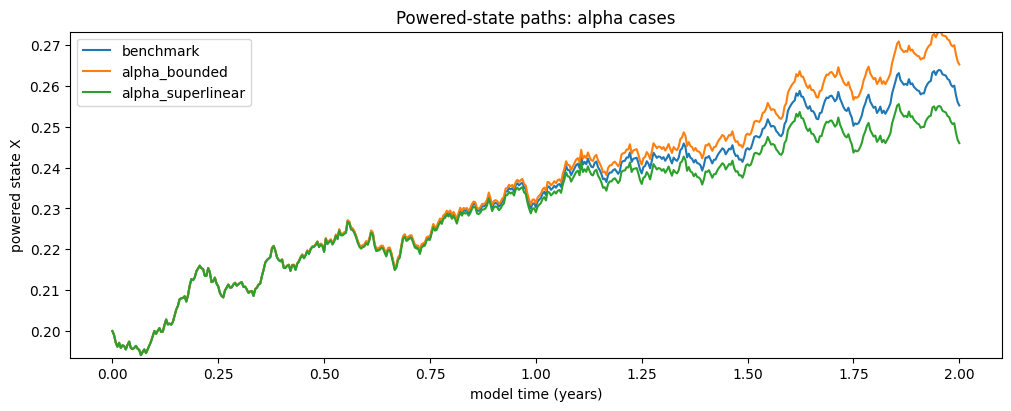

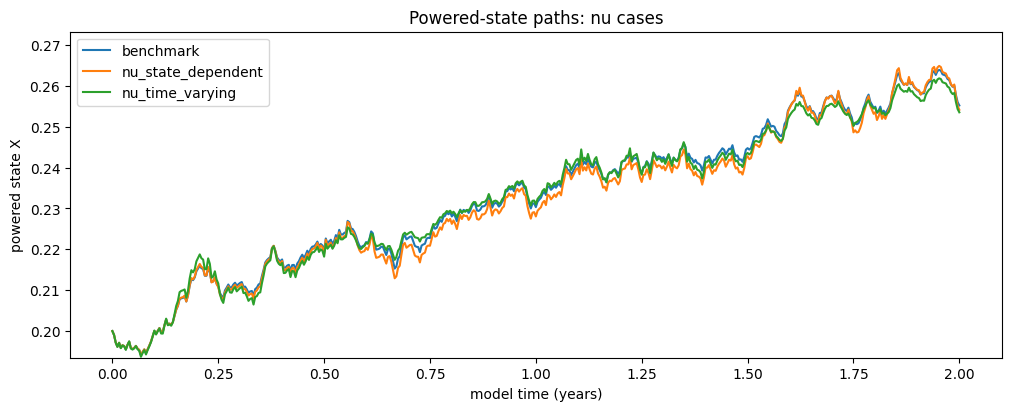

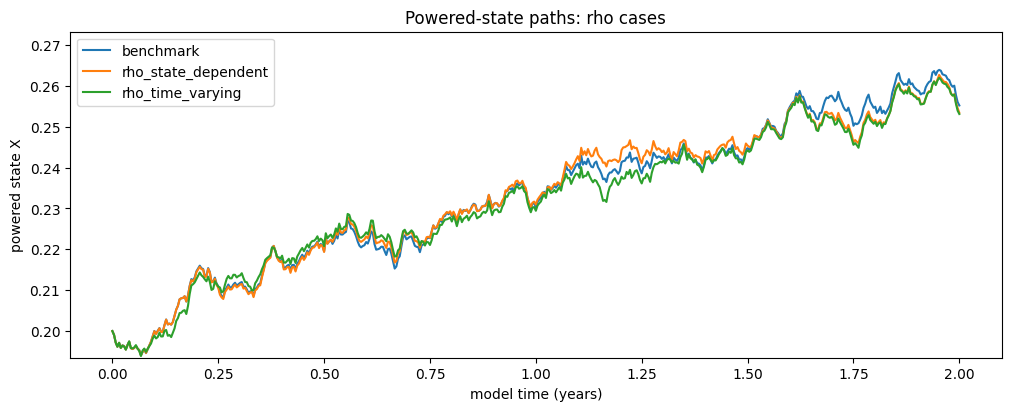

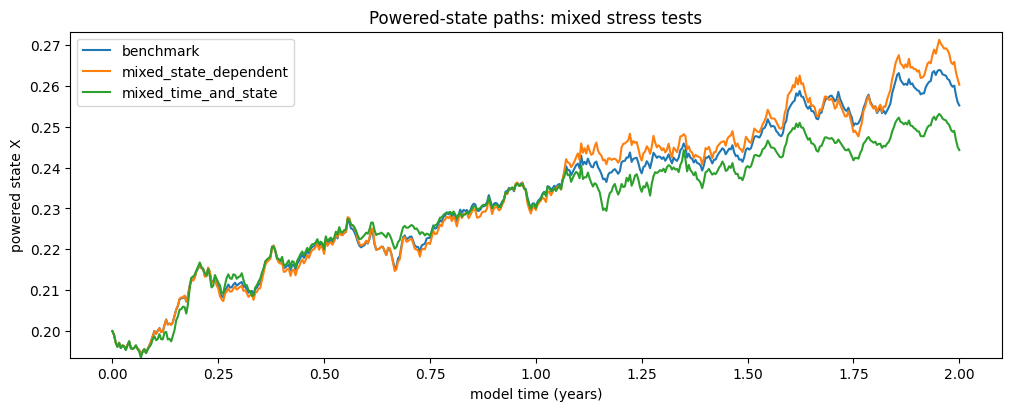

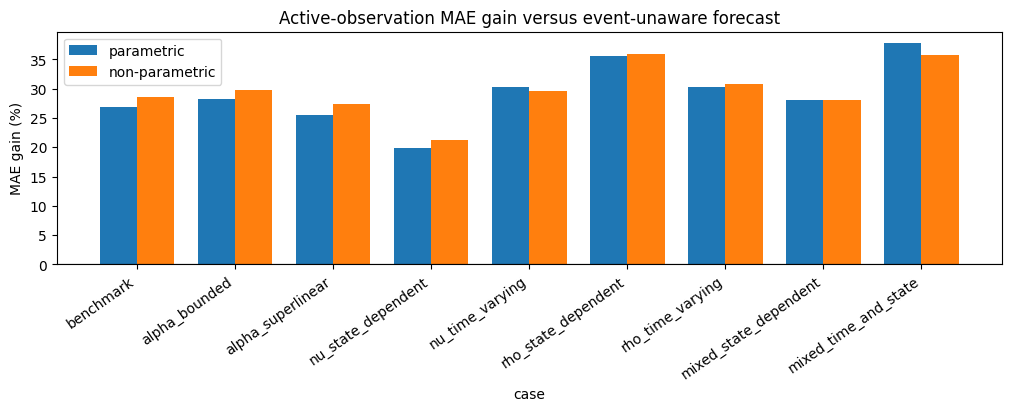

In [13]:
all_state_values = np.concatenate([result['simulation']['states']['x'].to_numpy() for result in case_results.values()])
state_ylim = (float(all_state_values.min()), float(all_state_values.max()))

def plot_state_paths(case_names, title):
    fig, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
    for name in case_names:
        states = case_results[name]['simulation']['states']
        axis.plot(states['t'], states['x'], label=name)
    axis.set(title=title, xlabel='model time (years)', ylabel='powered state X')
    axis.set_ylim(*state_ylim)
    axis.legend()
    plt.show()

plot_state_paths(['benchmark','alpha_bounded','alpha_superlinear'], 'Powered-state paths: alpha cases')
plot_state_paths(['benchmark','nu_state_dependent','nu_time_varying'], 'Powered-state paths: nu cases')
plot_state_paths(['benchmark','rho_state_dependent','rho_time_varying'], 'Powered-state paths: rho cases')
plot_state_paths(['benchmark','mixed_state_dependent','mixed_time_and_state'], 'Powered-state paths: mixed stress tests')

fig, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
positions = np.arange(len(primary_comparison))
width = 0.38
axis.bar(positions-width/2, primary_comparison['parametric_active_MAE_gain_pct'], width, label='parametric')
axis.bar(positions+width/2, primary_comparison['nonparametric_active_MAE_gain_pct'], width, label='non-parametric')
axis.axhline(0, color='black', linewidth=0.8)
axis.set(title='Active-observation MAE gain versus event-unaware forecast', xlabel='case', ylabel='MAE gain (%)')
axis.set_xticks(positions, primary_comparison['case_name'], rotation=35, ha='right')
axis.legend(); plt.show()


## Representative realised-versus-forecast paths

The quantitative MAE-gain results remain the main evidence; this figure is only an illustrative view of those gains. The target is the next volatility state, sigma_(i+1). Every plotted prediction comes from the held-out test period and is an already constructed forecast: no true future volatility or hidden simulator innovation is used to construct it.

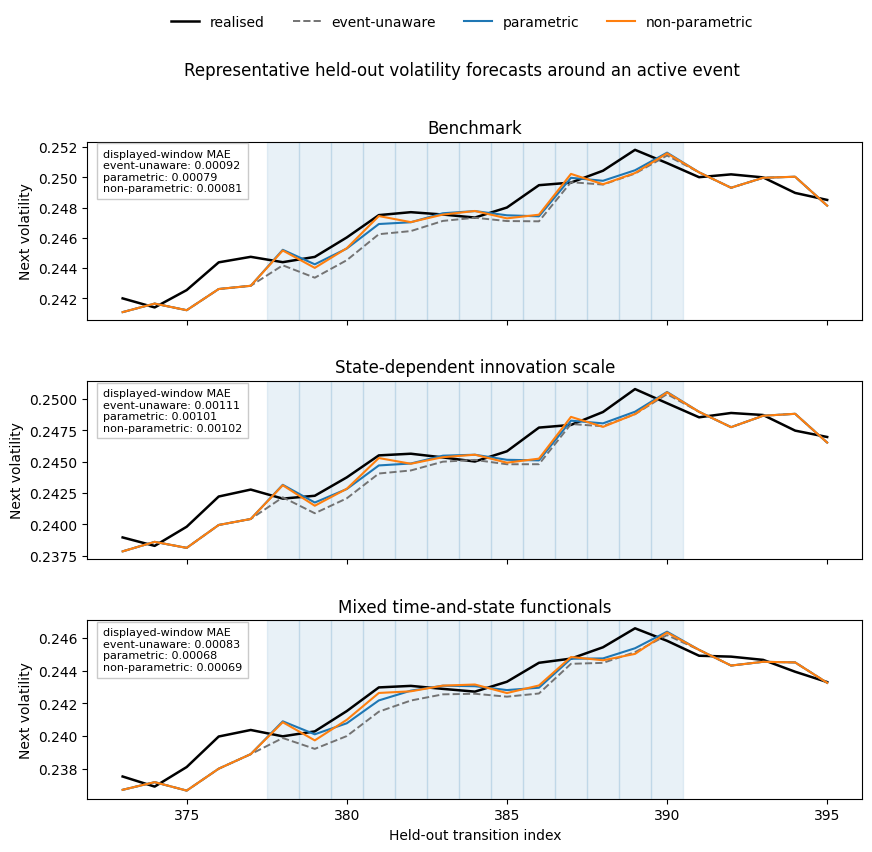

Representative held-out transition range: 373 to 395.


In [14]:
# Reuse the frozen held-out evaluation paths.  `i` is the forecast origin and
# every plotted realised value is sigma_(i+1), aligned to the same i/target_i pair.
representative_cases = ['benchmark', 'nu_state_dependent', 'mixed_time_and_state']
case_titles = {
    'benchmark': 'Benchmark',
    'nu_state_dependent': 'State-dependent innovation scale',
    'mixed_time_and_state': 'Mixed time-and-state functionals',
}
forecast_plot_columns = {
    'event-unaware': 'sigma_forecast_unaware',
    'parametric': 'sigma_forecast_parametric',
    'non-parametric': 'sigma_forecast_nonparametric',
}
alignment_columns = ['i', 'target_i', 'event_active_i', 'event_age_i']
plot_columns = alignment_columns + ['sigma_next'] + list(forecast_plot_columns.values())
held_out_paths = {}
for case_name in representative_cases:
    result = case_results[case_name]
    # Forecast inputs exclude sigma_next, so the constructed forecasts use no future target.
    assert 'sigma_next' not in result['forecast_inputs'].columns
    path = result['evaluation']['evaluation'].loc[:, plot_columns].sort_values('i').reset_index(drop=True)
    assert np.isfinite(path[['sigma_next', *forecast_plot_columns.values()]].to_numpy()).all()
    held_out_paths[case_name] = path

reference_path = held_out_paths['benchmark']
for case_name, path in held_out_paths.items():
    assert path[alignment_columns].equals(reference_path[alignment_columns])
    assert len(path) == len(reference_path)

# Pick the first complete active block that leaves five held-out observations on both sides.
active_mask = reference_path['event_active_i'].astype(bool)
block_start = active_mask & ~active_mask.shift(fill_value=False)
block_id = block_start.cumsum()
window_positions = None
for _, block in reference_path.loc[active_mask].groupby(block_id.loc[active_mask]):
    start, stop = int(block.index[0]), int(block.index[-1])
    complete_ages = np.array_equal(block['event_age_i'].to_numpy(), event_ages)
    consecutive = np.array_equal(block.index.to_numpy(), np.arange(start, stop + 1))
    if complete_ages and consecutive and start >= 5 and stop + 5 < len(reference_path):
        window_positions = np.arange(start - 5, stop + 6)
        break
assert window_positions is not None

representative_window = {
    case_name: path.iloc[window_positions].copy().reset_index(drop=True)
    for case_name, path in held_out_paths.items()
}
reference_window = representative_window['benchmark']
for case_name, window in representative_window.items():
    assert window[alignment_columns].equals(reference_window[alignment_columns])
    assert len(window) == len(window_positions)
    assert np.array_equal(window['event_active_i'].to_numpy(), reference_window['event_active_i'].to_numpy())

representative_window_maes = []
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
fig.subplots_adjust(top=0.84, hspace=0.34)
for axis, case_name in zip(axes, representative_cases):
    window = representative_window[case_name]
    for transition_i in window.loc[window['event_active_i'].astype(bool), 'i']:
        axis.axvspan(transition_i - 0.5, transition_i + 0.5, color='tab:blue', alpha=0.10, zorder=0)
    axis.plot(window['i'], window['sigma_next'], color='black', linewidth=1.8, label='realised')
    axis.plot(window['i'], window['sigma_forecast_unaware'], color='0.45', linestyle='--', linewidth=1.4, label='event-unaware')
    axis.plot(window['i'], window['sigma_forecast_parametric'], color='tab:blue', linewidth=1.5, label='parametric')
    axis.plot(window['i'], window['sigma_forecast_nonparametric'], color='tab:orange', linewidth=1.5, label='non-parametric')
    window_maes = {
        label: float(np.abs(window['sigma_next'] - window[column]).mean())
        for label, column in forecast_plot_columns.items()
    }
    representative_window_maes.append({'case_name': case_name, **window_maes})
    axis.text(0.02, 0.96, 'displayed-window MAE\n' + '\n'.join(f'{label}: {value:.5f}' for label, value in window_maes.items()), transform=axis.transAxes, va='top', fontsize=8, bbox={'facecolor':'white','alpha':0.82,'edgecolor':'0.75'})
    axis.set(title=case_titles[case_name], ylabel='Next volatility')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.995))
fig.suptitle('Representative held-out volatility forecasts around an active event', y=0.93)
axes[-1].set_xlabel('Held-out transition index')
plt.show()

representative_window_mae_table = pd.DataFrame(representative_window_maes)
for _, row in representative_window_mae_table.iterrows():
    window = representative_window[row['case_name']]
    for label, column in forecast_plot_columns.items():
        assert np.isclose(row[label], np.abs(window['sigma_next'] - window[column]).mean())
assert reference_window['event_active_i'].sum() == len(event_ages)
print(f"Representative held-out transition range: {int(reference_window['i'].min())} to {int(reference_window['i'].max())}.")


The forecasts target the next volatility state. Event-aware forecasts adjust the background prediction only during active event periods, and the visual gap can look small because volatility persistence already makes the event-unaware forecast reasonably strong. The MAE-gain calculations quantify whether these relatively small adjustments improve accuracy.

The benchmark is an intermediate case. The state-dependent innovation-scale case has weaker gains because state-dependent innovation noise makes the event component harder to isolate, whereas the mixed time-and-state case has stronger gains in the existing results and hence receives more value from the event-aware adjustment on this simulated path. This graph is illustrative, not stronger evidence than the full held-out MAE, RMSE and calibration summaries.

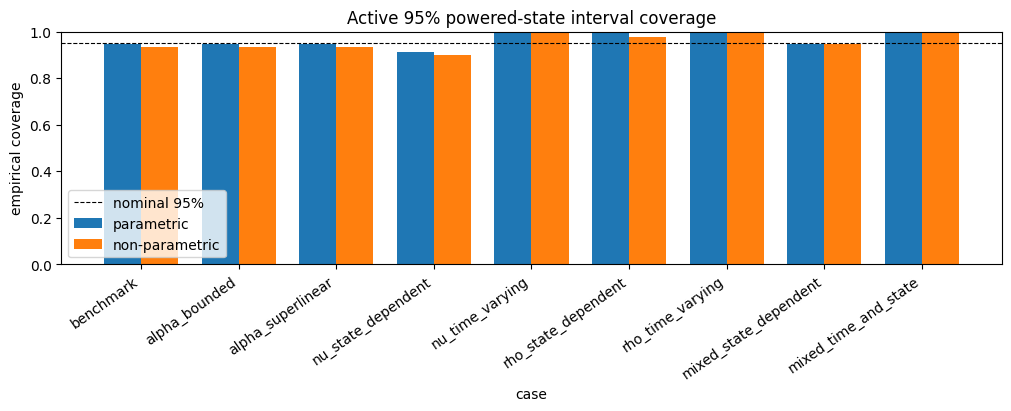

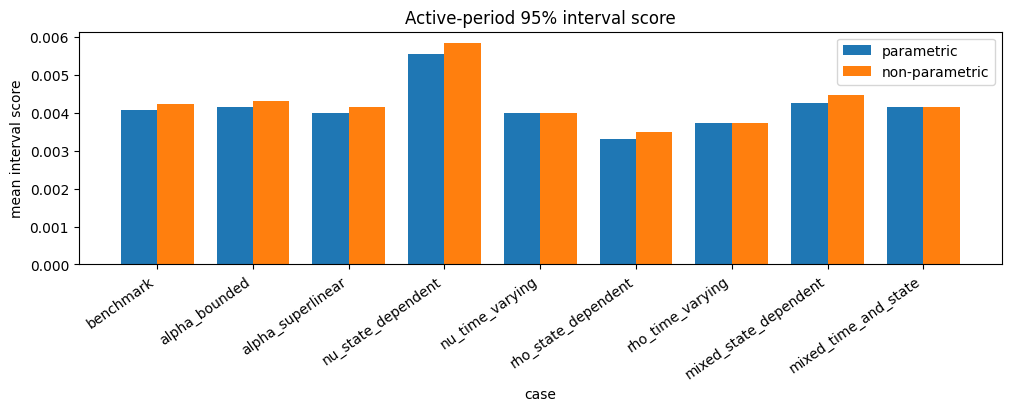

In [15]:
fig, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
axis.bar(positions-width/2, primary_comparison['parametric_active_95_coverage'], width, label='parametric')
axis.bar(positions+width/2, primary_comparison['nonparametric_active_95_coverage'], width, label='non-parametric')
axis.axhline(0.95, color='black', linestyle='--', linewidth=0.8, label='nominal 95%')
axis.set(title='Active 95% powered-state interval coverage', xlabel='case', ylabel='empirical coverage', ylim=(0,1))
axis.set_xticks(positions, primary_comparison['case_name'], rotation=35, ha='right')
axis.legend(); plt.show()

fig, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
axis.bar(positions-width/2, rmse_interval_detail['parametric_active_95_interval_score'], width, label='parametric')
axis.bar(positions+width/2, rmse_interval_detail['nonparametric_active_95_interval_score'], width, label='non-parametric')
axis.set(title='Active-period 95% interval score', xlabel='case', ylabel='mean interval score')
axis.set_xticks(positions, primary_comparison['case_name'], rotation=35, ha='right')
axis.legend(); plt.show()

## 12. Interpretation from this common-shock experiment

The following statements are generated from the current single-seed result. They are descriptive robustness evidence, not structural-causality claims. Historical GC and TDMI are dependence summaries; the conditional predictive-structure test remains distinct from Granger causality.

In [16]:
best_parametric_case = primary_comparison.loc[primary_comparison['parametric_active_MAE_gain_pct'].idxmax()]
worst_parametric_case = primary_comparison.loc[primary_comparison['parametric_active_MAE_gain_pct'].idxmin()]
coverage_distance = (primary_comparison['parametric_active_95_coverage'] - 0.95).abs()
maximum_coverage_distance = coverage_distance.max()
coverage_tie_cases = primary_comparison.loc[np.isclose(coverage_distance, maximum_coverage_distance)].merge(
    rmse_interval_detail[['case_name', 'parametric_active_95_interval_score']], on='case_name', how='left'
)
coverage_tie_records = coverage_tie_cases[[
    'case_name', 'parametric_active_95_coverage', 'parametric_active_95_interval_score'
]].round({'parametric_active_95_coverage': 3, 'parametric_active_95_interval_score': 6}).to_dict(orient='records')
state_range_case = primary_comparison.loc[(primary_comparison['state_max'] - primary_comparison['state_min']).idxmax()]

gc_level_by_case = historical_gc_table.loc[historical_gc_table['target'].eq('powered-state level')].set_index('case_name')
gc_change_by_case = historical_gc_table.loc[historical_gc_table['target'].eq('powered-state change')].set_index('case_name')
structure_by_case = conditional_predictive_structure_table.loc[conditional_predictive_structure_table['target'].eq('state_next')].set_index('case_name')
tdmi_level_by_case = tdmi_functional_table.loc[tdmi_functional_table['target'].eq('level')].set_index('case_name')
tdmi_change_by_case = tdmi_functional_table.loc[tdmi_functional_table['target'].eq('change')].set_index('case_name')

strongest_gc_case = gc_level_by_case['partial_R_squared'].idxmax()
weakest_gc_case = gc_level_by_case['partial_R_squared'].idxmin()
strongest_structure_case = structure_by_case['partial_r_squared'].idxmax()
level_lag_values = sorted(tdmi_level_by_case['direct_response_lag'].unique().tolist())
change_lag_values = sorted(tdmi_change_by_case['direct_response_lag'].unique().tolist())
all_gc_significant = bool(historical_gc_table['significant_5pct'].all())
level_sensitivity_peak_order = historical_gc_lag_sensitivity.loc[historical_gc_lag_sensitivity['target'].eq('powered-state level')].groupby('case_name')['partial_R_squared'].idxmax()
level_sensitivity_peak_orders = historical_gc_lag_sensitivity.loc[level_sensitivity_peak_order, ['case_name','lag_order']].sort_values('case_name').to_dict(orient='records')
lag_disagreement_cases = sorted(set(tdmi_level_by_case.index[tdmi_level_by_case['direct_response_lag'] != tdmi_change_by_case['direct_response_lag']]))

interpretation = f"""
### Findings from the single common-shock run

- The largest powered-state range occurs in **{state_range_case['case_name']}**. This is a changed simulated path under the common shocks, not an estimator redesign.
- Historical GC is significant at 5% for every reported target/case combination: **{all_gc_significant}**. For powered-state level, partial $R^2$ is strongest in **{strongest_gc_case}** and weakest in **{weakest_gc_case}**. The largest state-next conditional predictive-structure partial $R^2$ occurs in **{strongest_structure_case}**; this conditional test is not Granger causality.
- Direct-response TDMI level lags are {level_lag_values}; change lags are {change_lag_values}. Cases with differing level and change direct lags are {lag_disagreement_cases or 'none'}. TDMI magnitudes and lags therefore need not give the same message as linear GC under changed functionals.
- GC lag-order profiles are sensitivity diagnostics on a common effective sample. Their level partial-$R^2$ peak orders are {level_sensitivity_peak_orders}; each order $p$ jointly tests event lags 1 through $p$, rather than identifying an effect at lag $p$ alone.
- Parametric event-aware active MAE gain is largest in **{best_parametric_case['case_name']}** ({best_parametric_case['parametric_active_MAE_gain_pct']:.2f}%) and weakest in **{worst_parametric_case['case_name']}** ({worst_parametric_case['parametric_active_MAE_gain_pct']:.2f}%). Event-profile recovery and forecasting can move differently from dependence diagnostics when baseline dynamics are misspecified.
- The largest absolute parametric 95% coverage deviation is shared by {coverage_tie_records}. Their interval scores should be interpreted jointly with coverage: 100% empirical coverage is not automatically superior when it is achieved with wider or otherwise less sharp intervals. Good point forecasts would not by themselves establish calibrated intervals.
- Nonlinear alpha changes the conditional pre-event state; state-dependent nu changes both observed price-shock loading and latent innovation variance; state-dependent rho changes the share of volatility shock revealed through price movement. Time-varying nu or rho can therefore misspecify frozen constant-coefficient or constant-residual-variance components.

Historical GC is a linear predictive test. Under nonlinear data-generating dynamics, weaker GC evidence may reflect functional misspecification rather than absence of event dependence. TDMI can capture nonlinear dependence but is not by itself proof of structural causality. Estimated event parameters under misspecified baseline dynamics are not structural parameters, and the mixed cases are stress tests rather than isolated attribution experiments.
"""
display(Markdown(interpretation))


### Findings from the single common-shock run

- The largest powered-state range occurs in **alpha_bounded**. This is a changed simulated path under the common shocks, not an estimator redesign.
- Historical GC is significant at 5% for every reported target/case combination: **True**. For powered-state level, partial $R^2$ is strongest in **rho_time_varying** and weakest in **mixed_state_dependent**. The largest state-next conditional predictive-structure partial $R^2$ occurs in **rho_state_dependent**; this conditional test is not Granger causality.
- Direct-response TDMI level lags are [6, 7, 8, 9]; change lags are [1, 3, 9]. Cases with differing level and change direct lags are ['alpha_bounded', 'alpha_superlinear', 'benchmark', 'mixed_state_dependent', 'mixed_time_and_state', 'nu_state_dependent', 'nu_time_varying', 'rho_state_dependent', 'rho_time_varying']. TDMI magnitudes and lags therefore need not give the same message as linear GC under changed functionals.
- GC lag-order profiles are sensitivity diagnostics on a common effective sample. Their level partial-$R^2$ peak orders are [{'case_name': 'alpha_bounded', 'lag_order': 10}, {'case_name': 'alpha_superlinear', 'lag_order': 10}, {'case_name': 'benchmark', 'lag_order': 10}, {'case_name': 'mixed_state_dependent', 'lag_order': 10}, {'case_name': 'mixed_time_and_state', 'lag_order': 10}, {'case_name': 'nu_state_dependent', 'lag_order': 10}, {'case_name': 'nu_time_varying', 'lag_order': 10}, {'case_name': 'rho_state_dependent', 'lag_order': 10}, {'case_name': 'rho_time_varying', 'lag_order': 10}]; each order $p$ jointly tests event lags 1 through $p$, rather than identifying an effect at lag $p$ alone.
- Parametric event-aware active MAE gain is largest in **mixed_time_and_state** (37.85%) and weakest in **nu_state_dependent** (19.80%). Event-profile recovery and forecasting can move differently from dependence diagnostics when baseline dynamics are misspecified.
- The largest absolute parametric 95% coverage deviation is shared by [{'case_name': 'nu_time_varying', 'parametric_active_95_coverage': 1.0, 'parametric_active_95_interval_score': 0.003997}, {'case_name': 'rho_state_dependent', 'parametric_active_95_coverage': 1.0, 'parametric_active_95_interval_score': 0.003322}, {'case_name': 'rho_time_varying', 'parametric_active_95_coverage': 1.0, 'parametric_active_95_interval_score': 0.003725}, {'case_name': 'mixed_time_and_state', 'parametric_active_95_coverage': 1.0, 'parametric_active_95_interval_score': 0.004159}]. Their interval scores should be interpreted jointly with coverage: 100% empirical coverage is not automatically superior when it is achieved with wider or otherwise less sharp intervals. Good point forecasts would not by themselves establish calibrated intervals.
- Nonlinear alpha changes the conditional pre-event state; state-dependent nu changes both observed price-shock loading and latent innovation variance; state-dependent rho changes the share of volatility shock revealed through price movement. Time-varying nu or rho can therefore misspecify frozen constant-coefficient or constant-residual-variance components.

Historical GC is a linear predictive test. Under nonlinear data-generating dynamics, weaker GC evidence may reflect functional misspecification rather than absence of event dependence. TDMI can capture nonlinear dependence but is not by itself proof of structural causality. Estimated event parameters under misspecified baseline dynamics are not structural parameters, and the mixed cases are stress tests rather than isolated attribution experiments.


## Next controlled extension

The natural next step is paired Monte Carlo replication across common seeds, followed only later by an observable-feature augmentation ablation for cases where the frozen estimator performs poorly.